**MU en Bioinformática y Bioestadística**

*Arnau Mariscal Puig*

# *Objetivos*

Los objetivos de este trabajo incluyen:

**Objetivos generales**

•	Desarrollar y evaluar modelos predictivos a partir de variables acústicas de registros de voz para la clasificación de sujetos con enfermedad de Parkinson o sanos.

**Objetivos específicos**

•	Evaluar una estrategia de validación cruzada para cada forma de representación de los datos que evite una fuga de información.

•	Comparar el efecto de la unidad de análisis (registro de voz individual frente a agregación de registros por paciente) en el rendimiento predictivo.

•	Analizar el impacto de distintas estrategias de reducción de la dimensionalidad en el rendimiento y generalización de los modelos, incluyendo métodos de selección, extracción de características y selección de grupos de variables acústicas.

•	Examinar el efecto del desbalance de clases y de técnicas de remuestreo en el desempeño de los modelos.

•	Comparar el rendimiento distintos algoritmos de aprendizaje automático en la clasificación de pacientes con Parkinson y sujetos sanos.

•	Estudiar la interpretabilidad del modelo óptimo, identificando qué variables contribuyen en mayor medida a la clasificación.


# *Preparación del dataset*

## **Carga de librerías**

A continuación se cargan las librerías necesarias para correr el script. También se establece una configuración específica para los gráficos y así ofrecer una visualización homogénea.

In [ ]:
## Librerías a utilizar

#General
import numpy as np
import pandas as pd

#Gráficos
import matplotlib.pyplot as plt
import seaborn as sns

#Warnings
import warnings
warnings.filterwarnings("ignore")

#Pipeline
from sklearn.preprocessing import StandardScaler
from imblearn.pipeline import Pipeline as imbpipeline
from imblearn.over_sampling import SMOTE

# LOPO CV
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.model_selection import cross_validate

# CV para datos agregados
from sklearn.model_selection import StratifiedKFold

#Modelos
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import LinearSVC
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

#Métricas
from sklearn.metrics import accuracy_score, f1_score, matthews_corrcoef, roc_auc_score, make_scorer

#Selección de características
from sklearn.svm import LinearSVC
from sklearn.feature_selection import SelectFromModel
!pip install feature_engine -q
from feature_engine.selection import MRMR

#PCA
from sklearn.decomposition import PCA

#GridSearch
from sklearn.model_selection import GridSearchCV

#SHAP
import shap


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 243.5/243.5 kB 3.8 MB/s eta 0:00:00


In [ ]:
## Configuración de gráficos

#Paleta Seaborn
sns.set_theme(style='ticks', context='paper', font_scale=1.1)

#Paleta matplotlib
  #Paleta de colores (color-blind friendly)
okabe_ito = ['#E69F00', '#56B4E9', '#009E73', '#F0E442',
             '#0072B2', '#D55E00', '#CC79A7', '#000000']
plt.rcParams['axes.prop_cycle'] = plt.cycler(color=okabe_ito)

  #Tipografía:
    # Fuente
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.size'] = 8
    # Axis
plt.rcParams['axes.labelsize'] = 9
plt.rcParams['axes.titlesize'] = 9
    # Ticks
plt.rcParams['xtick.labelsize'] = 7
plt.rcParams['ytick.labelsize'] = 7
    # Leyenda
plt.rcParams['legend.fontsize'] = 7


# Referencia para la configuración gráfica
# https://lobehub.com/es/skills/sankalpsharmaa-claude-config-public-scientific-visualization?activeTab=skill#seaborn

## **Importación de datos**

El dataset “Parkinson's Disease Classification” ha sido descargado del repositorio “UC Irvine Machine Learning Repository”. La carpeta comprimida obtenida se sube a la carpeta '/My Drive/TFM/' de Google Drive, para su posterior extracción de datos.

In [ ]:
## Acceso a Google drive

from google.colab import drive
drive.mount('/content/drive/')

Mounted at /content/drive/


In [ ]:
## Extracción de dataset de carpeta comprimida (solo se realiza una primera vez)

#Instalar rarfile para extracción de archivo rar
#!apt-get install unrar
#!pip install rarfile

#Primero unzip de la carpeta comprimida
#!unzip '/content/drive/My Drive/TFM/parkinson_disease_classification_dataset.zip' -d '/content/drive/My Drive/TFM/parkinson_disease_classification_dataset/'

#Abrir archivo rar
#ruta_rar = '/content/drive/My Drive/TFM/parkinson_disease_classification_dataset/pd_speech_features.rar'
#carpeta_destino = '/content/drive/My Drive/TFM/'

#with rarfile.RarFile(ruta_rar) as archivo:
#    archivo.extractall(carpeta_destino)


# Bibliografia para unzip carpeta
# https://stackoverflow.com/questions/49685924/extract-google-drive-zip-from-google-colab-notebook
# https://stackoverflow.com/questions/50315989/how-to-extract-rar-files-inside-google-colab

In [ ]:
##Importación de datos

parkinson_data = pd.read_csv('/content/drive/My Drive/TFM/pd_speech_features.csv', skiprows=1, sep=",", decimal=".")

## **Descripción del dataset**

La base de datos incluye 756 registros y 755 columnas. Hay 2 variables categóricas, el **género** y la variable respuesta **diagnóstico**. También cuenta con 752 características acústicas numéricas y la variable **ID**, que permite identificar a qué sujeto pertenece cada registro. Si se agrupan los tres registros por ID, se percibe que la base de datos incluye a 252 pacientes. Se nombra al dataset "parkinson_data".

In [ ]:
parkinson_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 756 entries, 0 to 755
Columns: 755 entries, id to class
dtypes: float64(749), int64(6)
memory usage: 4.4 MB


## **Análisis de valores faltantes**

El análisis de valores faltantes para el dataset con registros totales, basado en un conteo y en una representación gráfica, no denota valores faltantes para ninguna variable.

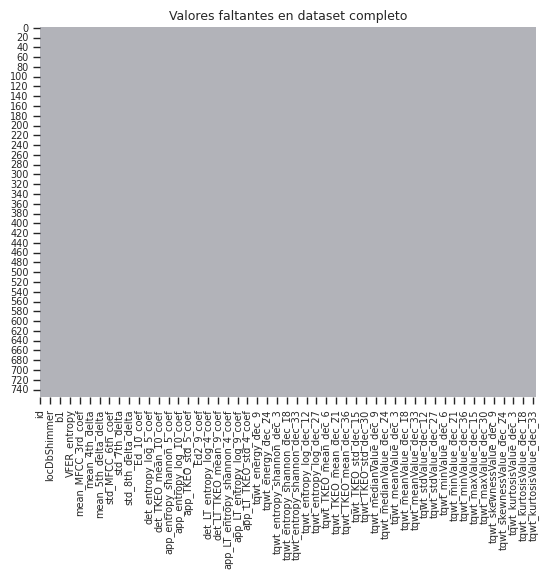

In [ ]:
## Observación de valores faltantes
# parkinson_data.isna().sum()

#Representación gráfica de valores faltantes
sns.heatmap(parkinson_data.isnull(), cbar=False, alpha=0.3)
plt.title("Valores faltantes en dataset completo")
plt.show()

#Visualizar NA values en formato gráfico
#https://stackoverflow.com/questions/69539114/how-to-visualize-missing-values-patterns-in-pandas

## **Limpieza del conjunto de datos**

Dada la ausencia de valores faltantes en el conjunto de datos, no será necesario su tratamiento mediante eliminación de filas o imputación de valores. Tampoco será necesaria una recodificación de variables, dado que las variables categóricas de interés, género y diagnóstico, ya han sido codificadas como variables numéricas binarias de tipo "one-hot encoding".

## **Dataset total vs dataset agregado**

Como estrategia alternativa para la clasificación de muestras de voz, se propone la creación de un dataset secundario elaborado a partir de la agregación de los tres registros por sujeto y la media para cada variable acústica.

In [ ]:
#Creamos el dataset de agregación de datos
parkinson_mean = (
    parkinson_data
    .groupby(by=["id"])
    .agg({
        "gender": "first",
        "class" : "first"})
    .join(parkinson_data.drop(columns=["gender", "class"]).groupby(by=["id"]).mean())
    .reset_index()
)

parkinson_mean.info()

#Bibliografía para la agregación de datos - group by
#https://pythongis.org/part1/chapter-03/nb/02-data-analysis.html#grouping-and-aggregating-data
#O'Reilly. Python for Data analysis. Wes McKinney

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 252 entries, 0 to 251
Columns: 755 entries, id to tqwt_kurtosisValue_dec_36
dtypes: float64(752), int64(3)
memory usage: 1.5 MB


# *Análisis Exploratorio de Datos (EDA)*

## **Descriptivos de variables categóricas**

El conjunto de datos incluye a 188 pacientes con EP (107 hombres y 81 mujeres) y 64 individuos sanos como grupo control (23 hombres y 41 mujeres). Por tanto, la mayoría de pacientes sanos son mujeres y la mayoría de diagnosticados de EP son hombres.

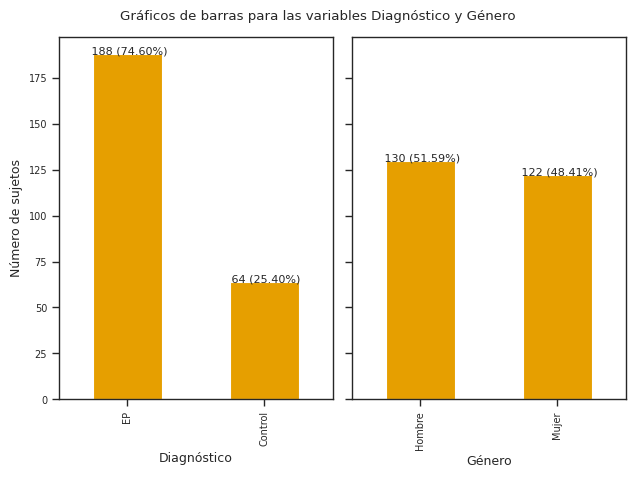

In [ ]:
## Barplots para Class (Diagnóstico) y Gender (Género)

# Para la representación de variables categóricas se utilizará el dataset parkinson_mean
# dado que contiene los datos agregados x paciente.

fig, axs = plt.subplots(1, 2, sharey=True, tight_layout=True)

def etiquetar_datos(valor, total):
  return f" {valor} ({valor/total*100:.2f}%)"

n_x_clase=parkinson_mean['class'].value_counts()
n_x_clase.plot(kind="bar", ax=axs[0])
axs[0].set_xticks([0, 1], ["EP", "Control"])
axs[0].set_xlabel("Diagnóstico")
axs[0].set_ylabel("Número de sujetos")

n_total=sum(n_x_clase)
for i, valor in enumerate(n_x_clase):
  axs[0].text(i, valor, etiquetar_datos(valor, n_total), ha='center')

n_x_genero = parkinson_mean['gender'].value_counts()
n_x_genero.plot(kind="bar", ax=axs[1])
axs[1].set_xticks([0, 1], ["Hombre", "Mujer"])
axs[1].set_xlabel("Género")
axs[1].set_ylabel("Número de sujetos")

n_total2=sum(n_x_genero)
for i, valor in enumerate(n_x_genero):
  axs[1].text(i, valor, etiquetar_datos(valor, n_total2), ha='center')

fig.suptitle("Gráficos de barras para las variables Diagnóstico y Género")
plt.show()


# Bibliografía para la cración de gráficos de barras
# https://www.geeksforgeeks.org/pandas/bar-plot-in-matplotlib/
# https://es.stackoverflow.com/questions/491570/c%C3%B3mo-ajustar-etiquetas-y-adem%C3%A1s-visualizar-etiquetas-con-los-porcentajes
# https://www.geeksforgeeks.org/python/matplotlib-pyplot-suptitle-function-in-python/


## **Descriptivos de variables contínuas**

A parte de las dos variables categóricas, hay 752 variables numéricas que representan las características acústicas. Se pude estudiar su distribución por los grupos definidos:

- 54 características **concat**: 21 características basales, 11 características tiempo-frecuencia y 22 características de las cuerdas vocales.
- 84 características **MFCC**  
- 182 características **WT**
- 432 características **TQWT**

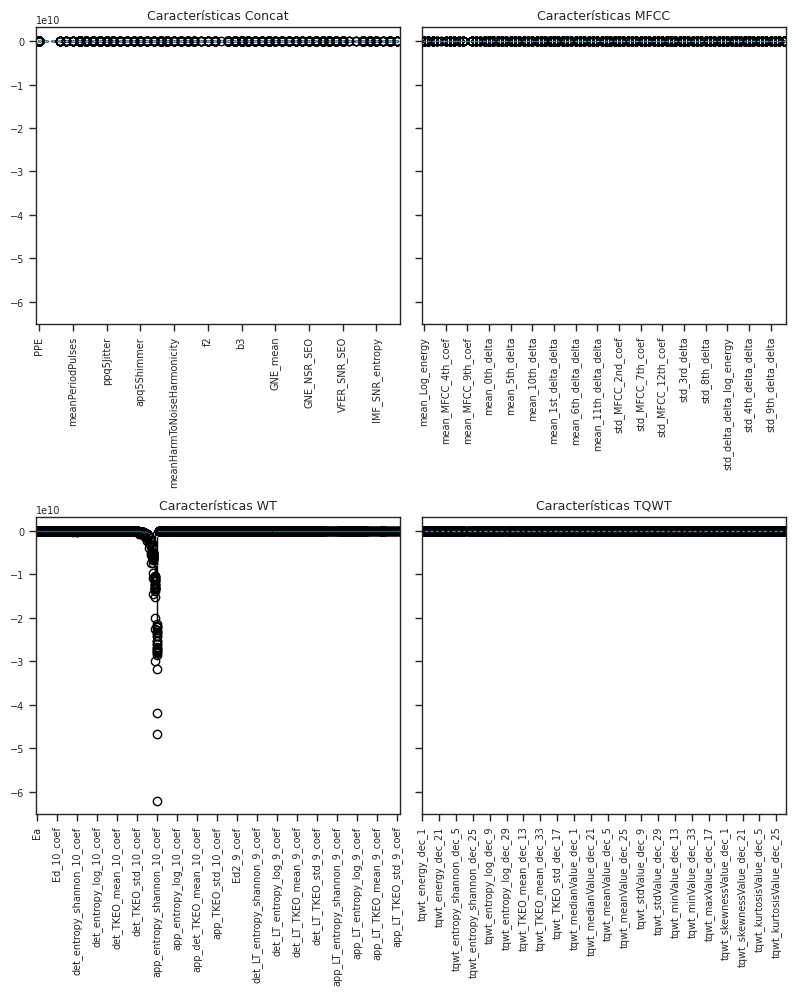

In [ ]:
## Grupos de variables acústicas
concat = parkinson_data.iloc[:, 2:56]
mfcc = parkinson_data.iloc[:, 56:140]
wavelet = parkinson_data.iloc[:, 140:322]
tqwt = parkinson_data.iloc[:, 322:754]

# Concat - X ticks
posiciones_c = np.arange(1, len(concat.columns) + 1)
seleccion_c = posiciones_c[::5]
etiquetas_c = concat.columns[::5]

# MFCC - X ticks
posiciones_mfcc = np.arange(1, len(mfcc.columns) + 1)
seleccion_mfcc = posiciones_mfcc[::5]
etiquetas_mfcc = mfcc.columns[::5]

# WT - X ticks
posiciones_wt = np.arange(1, len(wavelet.columns) + 1)
seleccion_wt = posiciones_wt[::10]
etiquetas_wt = wavelet.columns[::10]

# TQWT - X ticks
posiciones_tqwt = np.arange(1, len(tqwt.columns) + 1)
seleccion_tqwt = posiciones_tqwt[::20]
etiquetas_tqwt = tqwt.columns[::20]

#Plots
fig, axs = plt.subplots(2, 2, sharey=True, tight_layout=True, figsize=(8,10))

axs[0, 0].boxplot(concat)
axs[0, 0].set_xticks(seleccion_c, etiquetas_c, rotation=90)
axs[0, 0].set_title("Características Concat")

axs[0, 1].boxplot(mfcc)
axs[0, 1].set_xticks(seleccion_mfcc, etiquetas_mfcc, rotation=90)
axs[0, 1].set_title("Características MFCC")

axs[1, 0].boxplot(wavelet)
axs[1, 0].set_xticks(seleccion_wt, etiquetas_wt, rotation=90)
axs[1, 0].set_title("Características WT")

axs[1, 1].boxplot(tqwt)
axs[1, 1].set_xticks(seleccion_tqwt, etiquetas_tqwt, rotation=90)
axs[1, 1].set_title("Características TQWT")

plt.tight_layout()
plt.show()


La mayoría de las características presentan una distribución similar, excepto un conjunto de variables del grupo WT. Por esta razón, será necesario un escalado de los datos.

Dado que el número de variables predictoras es similar al número de registros en el dataset completo y aproximadamente el triple que el número de individuos, se considera explorar las variables contínuas en el espacio de los registros (los dos gráficos boxplot superiores) y los individuos (los dos gráficos boxplot inferiores).


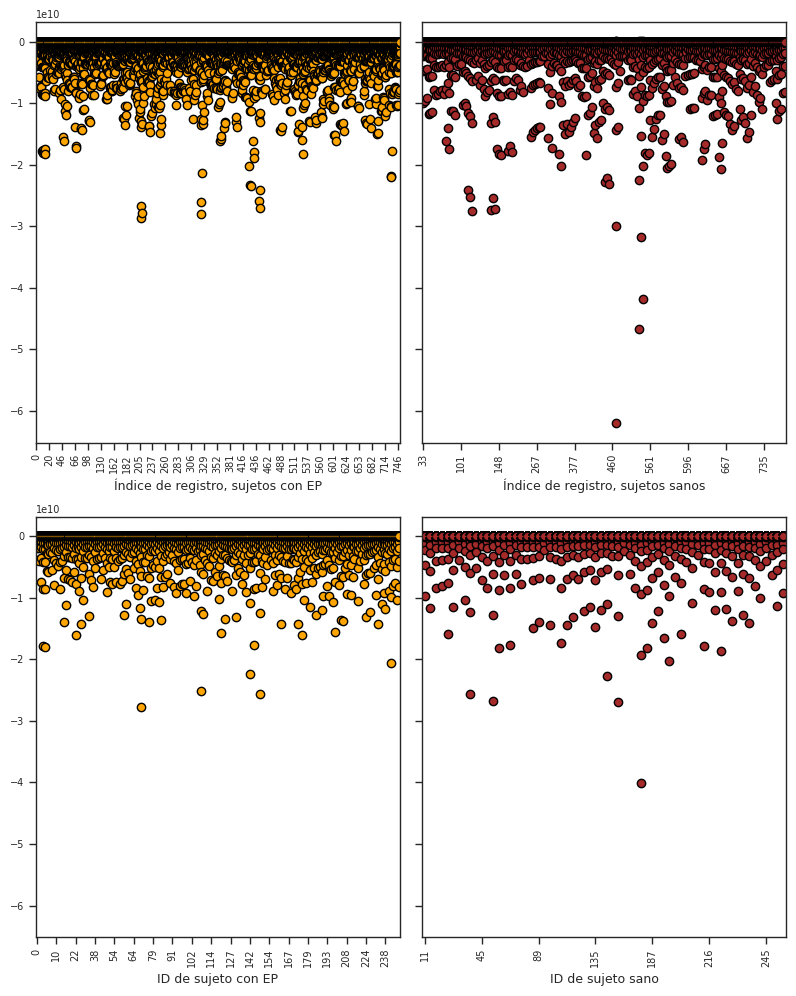

In [ ]:
# Boxplot de variables contínuas según registros (dataset completo) e individuos (dataset)

# Datos completos parkinson
pd_values1 = parkinson_data[parkinson_data["class"]==1].drop(["class", "gender", "id"], axis=1)
  #X ticks
n_registros00 = pd_values1.shape[0]
posiciones00 = np.arange(1, n_registros00 + 1)
seleccion00 = posiciones00[::20]
etiquetas00 = pd_values1.index[::20]

# Datos completos sanos
control_values1 = parkinson_data[parkinson_data["class"]==0].drop(["class", "gender", "id"], axis=1)
  #X ticks
n_registros01 = control_values1.shape[0]
posiciones01 = np.arange(1, n_registros01 + 1)
seleccion01 = posiciones01[::20]
etiquetas01 = control_values1.index[::20]

# Datos mean parkinson
pd_values2 = parkinson_mean[parkinson_mean["class"]==1].drop(["class", "gender", "id"], axis=1)
  #X ticks
n_registros10 = pd_values2.shape[0]
posiciones10 = np.arange(1, n_registros10 + 1)
seleccion10 = posiciones10[::10]
etiquetas10 = pd_values2.index[::10]

# Datos mean parkinson
control_values2 = parkinson_mean[parkinson_mean["class"]==0].drop(["class", "gender", "id"], axis=1)
  #X ticks
n_registros11 = control_values2.shape[0]
posiciones11 = np.arange(1, n_registros11 + 1)
seleccion11 = posiciones11[::10]
etiquetas11 = control_values2.index[::10]

#Plots
fig, axs = plt.subplots(2, 2, sharey=True, tight_layout=True, figsize=(8,10))

axs[0, 0].boxplot(pd_values1.T, flierprops=dict(markerfacecolor='orange'), medianprops=dict(color='orange')) # orientation="horizontal"
axs[0, 0].set_xlabel("Índice de registro, sujetos con EP")
axs[0, 0].set_xticks(seleccion00)
axs[0, 0].set_xticklabels(etiquetas00, rotation=90)

axs[0, 1].boxplot(control_values1.T, flierprops=dict(markerfacecolor='brown'), medianprops=dict(color='brown'))
axs[0, 1].set_xlabel("Índice de registro, sujetos sanos")
axs[0, 1].set_xticks(seleccion01)
axs[0, 1].set_xticklabels(etiquetas01, rotation=90)

axs[1, 0].boxplot(pd_values2.T, flierprops=dict(markerfacecolor='orange'), medianprops=dict(color='orange'))
axs[1, 0].set_xlabel("ID de sujeto con EP")
axs[1, 0].set_xticks(seleccion10)
axs[1, 0].set_xticklabels(etiquetas10, rotation=90)

axs[1, 1].boxplot(control_values2.T, flierprops=dict(markerfacecolor='brown'), medianprops=dict(color='brown'))
axs[1, 1].set_xlabel("ID de sujeto sano")
axs[1, 1].set_xticks(seleccion11)
axs[1, 1].set_xticklabels(etiquetas11, rotation=90)

plt.show()

# Bibilografía para la creación de boxplot
# https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.boxplot.html
# https://yasirbhutta.github.io/python/docs/plots-python/05-box-violin-plots/boxplot-matplotlib.html
# https://matplotlib.org/stable/gallery/ticks/ticks_too_many.html

Con esta representación visual no se ha podido determinar diferencias entre los sujetos sanos y con EP, aunque se puede percibir que los sujetos sanos contienen algunos individuos o registros con valores más extremos. Por otro lado, sí que ha permitido percibir diferencias entre los dos gráficos de los registros (gráficos superiores) y los dos gráficos que representan a los sujetos (gráficos inferiores): la variabilidad. La agregación de los tres registros en uno solo disminuye la presencia de valores atípicos y muestra una distribución más homogénea.

### *Análisis de correlación*

El análisis de correlación utiliza la métrica de correlación de Pearson para crear una matriz de correlación. De esta manera se identifican aquellas características altamente correlacionadas, que contienen información redundante y pueden provocar problemas de multicolinealidad.

364


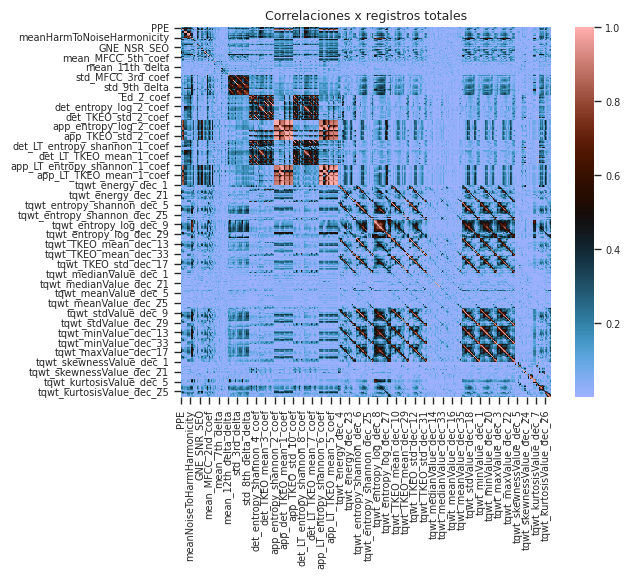

403


In [ ]:
#Análisis de correlación
v_continuas = parkinson_data.drop(["class", "id", "gender"], axis=1)

# Creación de una matriz de correlación
v_continuas = pd.DataFrame(v_continuas)
corr_matriz = v_continuas.corr().abs()
sns.heatmap(corr_matriz, cmap="berlin", square=True)
plt.title("Correlaciones x registros totales")

# Selección del triángulo superior de la matriz de correlación
t_sup = corr_matriz.where(np.triu(np.ones(corr_matriz.shape), k=1).astype(np.bool))

# Selección de las columnas con un índice de correlación superior a 0.90
a_eliminar = [column for column in t_sup.columns if any(t_sup[column] > 0.90)]
print(len(a_eliminar))

plt.show()


#Mismo análisis de correlación pero en dataset agregado:
v_continuas_mean = parkinson_mean.drop(["class", "id", "gender"], axis=1)

# Creación de una matriz de correlación
v_continuas_mean = pd.DataFrame(v_continuas_mean)
corr_matriz_mean = v_continuas_mean.corr().abs()

# Selección del triángulo superior de la matriz de correlación
t_sup2 = corr_matriz_mean.where(np.triu(np.ones(corr_matriz_mean.shape), k=1).astype(np.bool))

# Selección de las columnas con un índice de correlación superior a 0.90
a_eliminar2 = [column for column in t_sup2.columns if any(t_sup2[column] > 0.90)]
print(len(a_eliminar2))

#Machine Learning with Python Cookbook pag. 172
#https://www.geeksforgeeks.org/data-science/create-a-correlation-matrix-using-python/
#https://www.kaggle.com/code/saurav9786/seaborn-tutorial


La matriz de correlación en el conjunto de datos completo revela que, del total de 752 variables contínuas, 364 presentan coeficientes de Pearson superiores a 0.90. En el conjunto de datos agregado, el número de características acústicas alcanza a 403.

# *Desarrollo de modelos de clasificación basados en ML*

## **Escalado de datos**

Se procede a un escalado de datos para transformar las características acústicas a un mismo rango, lo cual es esencial para evitar que aquellas con valores más elevados tengan una mayor influencia en el modelo.

## **Estrategia de cross validation**

El conjunto de datos original cuenta con tres registros de voz por paciente, lo que exige una gestión adecuada para evitar una fuga de datos ("*data leakage*"). Para garantizar la robustez de los resultados con este dataset, se ha utilizado la estrategia *Leave-One-Person-Out Cross Validation* o *Leave-One-Group-Out Cross Validation* (LOPO CV).

Alternativamente, el dataset agregado elimina la posibilidad de fuga de datos entre registros del mismo paciente. Sin embargo el desbalance de clases observado en la variable diagnóstico aun es clara. Por esta razón, se opta en este caso con una Validación Cruzada Estratificada (Stratified K-Fold Cross-Validation).

## **Pipeline**

Para asegurar que las etapas de preprocesamiento de los datos se realizan solo con el conjunto de entrenamiento se utiliza la herramienta **Pipeline**. El Pipeline inicial incluye el *escalado de características* y el *algoritmo de clasificación*.

In [ ]:
#PIPELINE INICIAL
def pipeline_norm_base(modelo):
  steps=[
      ('scaler', StandardScaler()),
      ('model', modelo)
  ]
  return imbpipeline(steps)

## **Modelos de machine learning**

Para representar enfoques metodológicos diversos, se han aplicado distintos algoritmos de clasificación supervisada:

- Un modelo lineal basal: **Regresión Logística**
- Un modelo basado en distancia: **KNN**
- Un modelo lineal alternativo: **SVM con kernel lineal**
- Un modelo basado en kernel: **SVM con kernel RBF**
- Dos modelos basados en árboles: **Random forest** y **XGBoost**

Cada algoritmo presenta ventajas para la extracción de patrones, mostrando su capacidad para la predicción de la EP en cada caso.

A continuación se define la configuración basal para cada uno de los modelos.


In [ ]:
#Configuración basal de los modelos
seed = 123

#Regresión logística
RL = LogisticRegression(
    random_state=seed)

#k-Nearest Neighbors
KNN = KNeighborsClassifier(
    n_neighbors=15,
    n_jobs=-1)

# Support Vector Machine: Kernel lineal
SVM_linear = LinearSVC(
                 C=1.0,
                 random_state=seed)

# Support Vector Machine: Kernel RBF
SVM_rbf = SVC(
    kernel='rbf',
    C=1.0,
    random_state=seed,
    probability=False)

#Random forest
RF = RandomForestClassifier(
    n_estimators=100,
    random_state=seed,
    n_jobs=-1)

#Gradient boosting: XGboost
XGboost = XGBClassifier(
    n_estimators=100,
    random_state=seed,
    n_jobs=-1)

#Lista de modelos
lista_modelos = {"Regresión Logística": RL, "KNN": KNN, "SVM (lineal)":SVM_linear, "SVM (rbf)": SVM_rbf, "Random Forest": RF, "XGBoost": XGboost}


# Bibliografía para el desarrollo de los modelos:

# KNN
# https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html
# SVC
# https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html
# https://stackoverflow.com/questions/47312432/attributeerrorlinearsvc-object-has-no-attribute-predict-proba
# RF
# https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html
# Linear SVC
# https://scikit-learn.org/stable/modules/generated/sklearn.svm.LinearSVC.html
# SVC
# https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html
# Logistic regression
# https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html
# XGBoost
# https://xgboost.readthedocs.io/en/release_3.2.0/

# Libros:
# Machine learning with R. Brett Lantz
# Exploring Binary Classification Modelos for PD Detection


## **Métricas de evaluación de rendimiento**

Para valorar el rendimiento de los modelos se han tenido en cuenta las siguientes métricas: **exactitud** ("accuracy"), **F1-score**, **MCC** ("Matthews correlation coefficient") y **AUC-ROC** (Área Bajo la Curva). Todas ellas derivan de los valores de la Matriz de Confusión, que clasifica los resultados de la predicción del algoritmo en: Verdaderos Positivos (TP), Verdaderos Negativos (TN), Falsos Positivos (FP) y Falsos Negativos (FN).


In [ ]:
#Métricas

metricas = {"Accuracy": 'accuracy_score', "F1-score": 'f1_score', "MCC": 'matthews_corrcoef', "AUC-ROC": 'roc_auc_score'}


# Bibliografía para las métricas
# Accuracy
# https://scikit-learn.org/stable/modules/generated/sklearn.metrics.accuracy_score.html
# MCC
# https://scikit-learn.org/stable/modules/generated/sklearn.metrics.matthews_corrcoef.html
# F1_score
# https://scikit-learn.org/stable/modules/generated/sklearn.metrics.f1_score.html
# roc_auc
# https://scikit-learn.org/stable/modules/generated/sklearn.metrics.roc_auc_score.html

## **Unidad de análisis: Datos completos vs datos agregados**

Antes de proceder a analizar cada uno de los algoritmos, se ha considerado la evaluación de los datos sobre los que se medirá su rendimiento: la unidad de análisis. Se ha examinado cuál es la unidad de análisis más adecuada, comparando el rendimiento de los modelos de Regresión Logística y Random Forest sobre el dataset completo y el agregado.

In [ ]:
## Modelos para la comparación de la unidad de análisis

seed=123

#Random forest
RF = RandomForestClassifier(
    n_estimators=100,
    random_state=seed,
    n_jobs=-1)

#Regresión logística
RL = LogisticRegression(
    random_state=seed)

lista_unidad_analisis = {"Regresión Logística": RL, "Random Forest": RF}

In [ ]:
## Dataset completo - estrategia de validación cruzada LOGO CV

# Datos completos, separación x e y
y1 = parkinson_data["class"]
X1 = parkinson_data.drop(["class", "id"], axis=1)

# LOPO CV
logo = LeaveOneGroupOut()
sujetos=parkinson_data["id"]

def make_metricas(pipeline, modelo, X, y, grupo):

  # print("Entrenando modelo:", {modelo})

  #Para cálculo de métricas
  y_test_postcv = [] #lista y_test con diagnosticos reales (post cv)
  y_test_prediccion = [] #lista con diagnosticos predichos
  y_probabilidades = [] #probabilidad de diagnóstico (necesario para auc-roc)

  #Modelo con CV LOPO
  for train_index, test_index in logo.split(X, y, grupo):
    X_train = X.iloc[train_index]
    y_train = y.iloc[train_index]
    X_test = X.iloc[test_index]
    y_test = y.iloc[test_index]

    #Pipeline
    pipeline_ml = pipeline(modelo)

    pipeline_ml.fit(X_train, y_train)

    #Predicciones
    predicciones = pipeline_ml.predict(X_test)

    if isinstance(modelo, (LinearSVC, SVC)):
      prob_predicciones = pipeline_ml.decision_function(X_test)
    else:
      prob_predicciones = pipeline_ml.predict_proba(X_test)[:, 1] #necesario para el cálculo de auc-roc

    #Añadirlas a las listas
    y_test_prediccion.extend(predicciones)
    y_probabilidades.extend(prob_predicciones)
    y_test_postcv.extend(y_test)

  #Cálculo de métricas
  metricas = {
      'Accuracy': accuracy_score(y_test_postcv, y_test_prediccion),
      'F1-score': f1_score(y_test_postcv, y_test_prediccion),
      'MCC': matthews_corrcoef(y_test_postcv, y_test_prediccion),
      'AUC-ROC': roc_auc_score(y_test_postcv, y_probabilidades)}

  # Crear DataFrame de una fila
  metricas_df = pd.DataFrame([metricas]).round(3)
  return metricas_df

# Función tabla summary para juntar los resultados de todos los modelos
def tabla_summary_modelos(pipeline, modelos, X, y, grupo):
  tabla_resumen = pd.DataFrame()
  for (key, value) in modelos.items():
    modelo_resumen = make_metricas(pipeline, value, X, y, grupo)
    modelo_resumen['Modelo'] = str(key)
    tabla_resumen = pd.concat([tabla_resumen, modelo_resumen])
  return tabla_resumen

# Bibliografía para el desarrollo del pipeline
#concat python as rbind
#https://stackoverflow.com/questions/14988480/pandas-version-of-rbind
#iterating over a dictionary
#https://stackoverflow.com/questions/69205854/iterating-over-dictionary-in-python-and-using-each-value
#paste0 in pyhton
#https://stackoverflow.com/questions/50653208/paste0-like-function-in-python-for-multiple-strings

#Bibliografia LOGO
#https://scikit-learn.org/stable/modules/cross_validation.html#the-cross-validate-function-and-multiple-metric-evaluation
#https://stackoverflow.com/questions/66734121/how-to-apply-leave-one-group-out-cross-validation-in-sklearn
#https://github.com/scikit-learn/scikit-learn/discussions/27091
#https://www.kaggle.com/code/mehrankazeminia/1-tps-jul-21-xgboost-leaveonegroupout/notebook

#Extend vs append
#https://stackoverflow.com/questions/14446128/append-vs-extend-efficiency

#is instance
#https://www.geeksforgeeks.org/python/python-isinstance-method/

#Solución de bugs
#https://stackoverflow.com/questions/40329576/sklearn-pass-fit-parameters-to-xgboost-in-pipeline
#https://www.geeksforgeeks.org/machine-learning/why-is-scikit-learn-svmsvc-extremely-slow/
#https://ai.stackexchange.com/questions/7202/why-does-training-an-svm-take-so-long-how-can-i-speed-it-up


In [ ]:
## Dataset agregado - estrategia de validación cruzada StratifiedKFold

# Utilizamos la estructura de la estrategia de LOGO CV, pero implementamos Stratified KFold
y2 = parkinson_mean['class']
X2 = parkinson_mean.drop(['class', 'id'], axis=1)

kf = StratifiedKFold(n_splits=10, shuffle=True, random_state=123)

def make_metricas2(pipeline, modelo, X, y):

  # print("Entrenando modelo:", {modelo})

  y_test_postcv = []
  y_test_prediccion = []
  y_probabilidades = []

  for train_index, test_index in kf.split(X, y):
    X_train = X.iloc[train_index]
    y_train = y.iloc[train_index]
    X_test = X.iloc[test_index]
    y_test = y.iloc[test_index]

    #Pipeline
    pipeline_ml = pipeline(modelo)

    pipeline_ml.fit(X_train, y_train)

    #Predicciones
    predicciones = pipeline_ml.predict(X_test)

    if isinstance(modelo, (LinearSVC, SVC)):
      prob_predicciones = pipeline_ml.decision_function(X_test)
    else:
      prob_predicciones = pipeline_ml.predict_proba(X_test)[:, 1] #necesario para el cálculo de auc-roc

    #Añadirlas a las listas
    y_test_prediccion.extend(predicciones)
    y_probabilidades.extend(prob_predicciones)
    y_test_postcv.extend(y_test)

  #Cálculo de métricas
  metricas = {
      'Accuracy': accuracy_score(y_test_postcv, y_test_prediccion),
      'F1-score': f1_score(y_test_postcv, y_test_prediccion),
      'MCC': matthews_corrcoef(y_test_postcv, y_test_prediccion),
      'AUC-ROC': roc_auc_score(y_test_postcv, y_probabilidades)}

  # Crear DataFrame de una fila
  metricas_df = pd.DataFrame([metricas]).round(3)

  return metricas_df

def tabla_summary_modelos2(pipeline, modelos, X, y):
  tabla_resumen = pd.DataFrame()
  for (key, value) in modelos.items():
    modelo_resumen = make_metricas2(pipeline, value, X, y)
    modelo_resumen['Modelo'] = str(key)
    tabla_resumen = pd.concat([tabla_resumen, modelo_resumen])
  return tabla_resumen

#Bibilografía para la validación cruzada startified k fold
#https://medium.com/@pacosun/cross-validation-techniques-ensuring-your-model-generalizes-well-2f5b4f58be0f
#https://scikit-learn.org/stable/modules/cross_validation.html
#https://www.geeksforgeeks.org/machine-learning/stratified-k-fold-cross-validation/

In [ ]:
# ## Resultados conjunto de datos completo (12 min)
resultados_unidad_analisis1 = tabla_summary_modelos(pipeline_norm_base, lista_unidad_analisis, X1, y1, sujetos)

# ## Resultados conjunto de datos agregado (9 s)
resultados_unidad_analisis2 = tabla_summary_modelos2(pipeline_norm_base, lista_unidad_analisis, X2, y2)

## Resultados finales
datos1 = ['datos_completos', 'datos_completos', 'datos_agregados', 'datos_agregados']

resultados_unidad_analisis = pd.concat([resultados_unidad_analisis1, resultados_unidad_analisis2])
resultados_unidad_analisis["Datos"] = datos1

resultados_unidad_analisis

,Accuracy,F1-score,MCC,AUC-ROC,Modelo,Datos
0,0.778,0.850,0.422,0.799,Regresión Logística,datos_completos
0,0.829,0.892,0.508,0.846,Random Forest,datos_completos
0,0.806,0.873,0.459,0.822,Regresión Logística,datos_agregados
0,0.837,0.899,0.530,0.834,Random Forest,datos_agregados


Los resultados de la prueba revelan que ambos modelos presentan una mejor capacidad de clasificación de los sujetos con el dataset agregado. Esto indica que la agregación de los datos elimina el ruido de los registros individuales, mejorando la capacidad de discriminación de los modelos.

La simplicidad del dataset agregado, su significativo menor tiempo de computación y los mejores resultados de rendimiento han orientado al trabajo con este conjunto de datos transformado.

## **Resultados de rendimiento base**

Teniendo en cuenta el uso del dataset agregado, con validación cruzada estratificada, se evalúan todos los modelos presentados sin modificación de hiperparámetros. En este momento, aun no hay tratamiento del desbalance de clases ni selección de características

In [ ]:
#Resultados base (40 s)
resultados_base = tabla_summary_modelos2(pipeline_norm_base, lista_modelos, X2, y2)
resultados_base

,Accuracy,F1-score,MCC,AUC-ROC,Modelo
0,0.806,0.873,0.459,0.822,Regresión Logística
0,0.782,0.871,0.317,0.810,KNN
0,0.802,0.863,0.505,0.833,SVM (lineal)
0,0.813,0.886,0.446,0.812,SVM (rbf)
0,0.837,0.899,0.530,0.834,Random Forest
0,0.817,0.884,0.476,0.864,XGBoost


# Reducción de la dimensionalidad

Un alto número de variables predictoras puede afectar el rendimiento de los modelos utilizados si las características llegan a ser redundantes o irrelevantes. Ante esta situación, se pueden aplicar estrategias para la reducción de la dimensionalidad, que permiten simplificar los datos y reducir el número de variables predictoras, conservando aquellas más importanes. En concreto, se han aplicado tres métodos de selección de características y uno de extracción de características.

## **Selección de características**

**Selección de características - LinearSVC**

Es un modelo lineal basado en SVM que también puede aplicarse como método de selección de características. El parámetro C controla la dispersión, de modo que cuanto menor sea C menos características son seleccionadas.

Se define un nuevo pipeline con un paso adicional de selección de características mediante LinearSVC.


In [ ]:
#Pipeline con selección de características LinearSVC

def pipeline_norm_linearsvc(modelo, C):
  steps=[
      ('scaler', StandardScaler()),
      ('feature_selection', SelectFromModel(LinearSVC(penalty="l1", loss="squared_hinge", C=C, random_state=123))),
      ('model', modelo)
  ]
  return imbpipeline(steps)

A continuación, se explora el valor de coste C óptimo entre un rango de posibles valores teniendo en cuenta el rendimiento de los modelos de RL y RF según la métrica MCC.

In [ ]:
#Función para explorar el valor de características óptimo a seleccionar
def make_metricas3(pipeline, rango_i, modelo, X, y):

  y_test_postcv = []
  y_test_prediccion = []

  for train_index, test_index in kf.split(X, y):
    X_train = X.iloc[train_index]
    y_train = y.iloc[train_index]
    X_test = X.iloc[test_index]
    y_test = y.iloc[test_index]

    #Pipeline
    pipeline_ml = pipeline(modelo, rango_i)

    pipeline_ml.fit(X_train, y_train)

    #Predicciones
    predicciones = pipeline_ml.predict(X_test)

    #Añadirlas a las listas
    y_test_prediccion.extend(predicciones)
    y_test_postcv.extend(y_test)

  return matthews_corrcoef(y_test_postcv, y_test_prediccion)

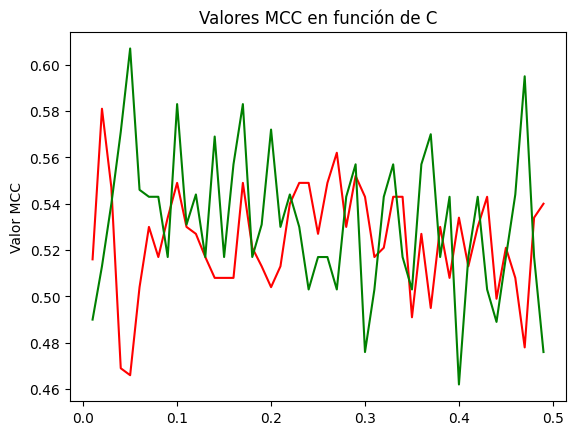

Mejor valor de C 0.1


In [ ]:
#Selección del uso de C
# (se han probado valores de rendimiento hasta C=10, pero los valores entre 0.01 y 0.5 dan los mejores resultados)
rango = np.arange(0.01, 0.5, 0.01)

tabla_resultado = pd.DataFrame()
for rango_i in rango:
  #print("Entrenando con rango:", rango_i)
  result_i_RF = make_metricas3(pipeline_norm_linearsvc, rango_i, lista_modelos['Random Forest'], X2, y2)
  result_i_RL = make_metricas3(pipeline_norm_linearsvc, rango_i, lista_modelos['Regresión Logística'], X2, y2)

  metricas = {
    'rango_num': rango_i,
    'mcc_RF': result_i_RF,
    'mcc_RL': result_i_RL}

  tabla_i = pd.DataFrame([metricas]).round(3)
  tabla_resultado = pd.concat([tabla_resultado, tabla_i], ignore_index=True)

tabla_resultado

#Plot para observar distintos valores de C
plt.plot(tabla_resultado['rango_num'], tabla_resultado['mcc_RL'], 'r')
plt.plot(tabla_resultado['rango_num'], tabla_resultado['mcc_RF'], 'g')
plt.title("Valores MCC en función de C")
plt.ylabel("Valor MCC")
plt.show()

#Calculamos la media de los mejores resultados de MCC para determinar cual es la mejor C
tabla_resultado['mcc_promedio'] = (tabla_resultado['mcc_RF'] + tabla_resultado['mcc_RL']) / 2
tabla_resultado.reset_index(drop=True)
print("Mejor valor de C", tabla_resultado.loc[tabla_resultado['mcc_promedio'].idxmax(), "rango_num"])

Finalmente, se evalúa el rendimiento de los modelos teniendo en cuenta el valor de C óptimo.

In [ ]:
#Rendimiento de los modelos con selección de características LinearSVC

def pipeline_norm_linearsvc_def(modelo):
  steps=[
      ('scaler', StandardScaler()),
      ('feature_selection', SelectFromModel(LinearSVC(penalty="l1", loss="squared_hinge", C=0.1, random_state=123))),
      ('model', modelo)
  ]
  return imbpipeline(steps)


resultados_linearsvc = tabla_summary_modelos2(pipeline_norm_linearsvc_def, lista_modelos, X2, y2)
resultados_linearsvc

,Accuracy,F1-score,MCC,AUC-ROC,Modelo
0,0.837,0.894,0.549,0.819,Regresión Logística
0,0.782,0.872,0.330,0.819,KNN
0,0.794,0.859,0.473,0.812,SVM (lineal)
0,0.853,0.908,0.582,0.811,SVM (rbf)
0,0.853,0.909,0.583,0.845,Random Forest
0,0.829,0.892,0.509,0.856,XGBoost


**Selección de características - mRMR**

Pertenece a la librería feature_engine y evalúa la relevancia de las características mediante el estadístico F obtenido a partir de ANOVA, mientras que la redundancia la calcula a partir del coeficiente de correlación de Pearson.

A continuación se define un nuevo pipeline con selección de características mediante mRMR. También se explora el número de características óptimo, en este caso en un rango entre 10 y 50, dado al alto coste computacional de esta técnica. Con el número óptimo de variables se evalúa el rendimiento predictivo de los modelos con este pipeline.

In [ ]:
# Pipeline con selección de características mRMR

def pipeline_norm_mrmr(modelo, n_features):
    steps = [
        ('scaler', StandardScaler()),
        ('feature_selection', MRMR(method="FCQ", regression=False, random_state=123, max_features=n_features)),
        ('model', modelo)
    ]
    return imbpipeline(steps)

# Bibliografía para el desarrollo de mRMR
# https://feature-engine.trainindata.com/en/1.8.x/api_doc/selection/MRMR.html#feature_engine.selection.MRMR.fit

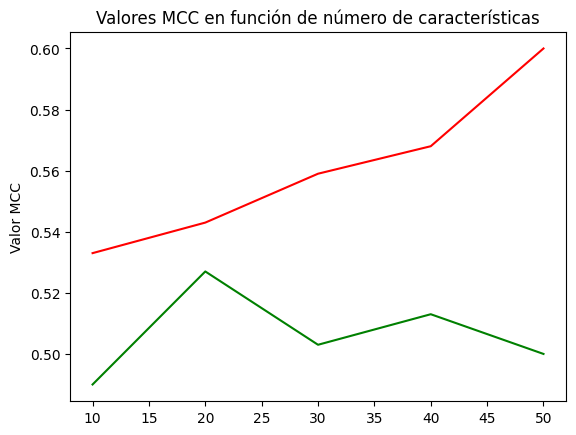

Mejor valor de N características =  50


In [ ]:
# Encontrar el número de características óptimo
rango = range(10, 60, 10)

tabla_resultado = pd.DataFrame()
for rango_i in rango:
  #print("Entrenando con rango:", rango_i)
  result_i_RF = make_metricas3(pipeline_norm_mrmr, rango_i, lista_modelos['Random Forest'], X2, y2)
  result_i_RL = make_metricas3(pipeline_norm_mrmr, rango_i, lista_modelos['Regresión Logística'], X2, y2)

  metricas = {
    'rango_num': rango_i,
    'mcc_RF': result_i_RF,
    'mcc_RL': result_i_RL}

  tabla_i = pd.DataFrame([metricas]).round(3)
  tabla_resultado = pd.concat([tabla_resultado, tabla_i], ignore_index=True)

tabla_resultado

#Plot para observar distintos valores de C
plt.plot(tabla_resultado['rango_num'], tabla_resultado['mcc_RL'], 'r')
plt.plot(tabla_resultado['rango_num'], tabla_resultado['mcc_RF'], 'g')
plt.title("Valores MCC en función de número de características")
plt.ylabel("Valor MCC")
plt.show()

#Calculamos la media de los mejores resultados de MCC para determinar cual es la mejor C
tabla_resultado['mcc_promedio'] = (tabla_resultado['mcc_RF'] + tabla_resultado['mcc_RL']) / 2
tabla_resultado.reset_index(drop=True)
print("Mejor valor de N características = ", tabla_resultado.loc[tabla_resultado['mcc_promedio'].idxmax(), "rango_num"])

In [ ]:
#Rendimiento de los modelos mediante selección de características mRMR

def pipeline_norm_mrmr_def(modelo):
    steps = [
        ('scaler', StandardScaler()),
        ('feature_selection', MRMR(method="FCQ", regression=False, random_state=123, max_features=50)),
        ('model', modelo)
    ]
    return imbpipeline(steps)

resultados_mrmr = tabla_summary_modelos2(pipeline_norm_mrmr_def, lista_modelos, X2, y2)
resultados_mrmr

,Accuracy,F1-score,MCC,AUC-ROC,Modelo
0,0.853,0.903,0.600,0.864,Regresión Logística
0,0.829,0.895,0.503,0.832,KNN
0,0.837,0.893,0.556,0.845,SVM (lineal)
0,0.841,0.898,0.550,0.805,SVM (rbf)
0,0.825,0.889,0.500,0.846,Random Forest
0,0.821,0.886,0.490,0.846,XGBoost


**Selección de características - Grupos de características acústicas**

Dada la diferente información aportada por cada uno de los grupos de características acústicas (MFCC, TQWT, WT y Concat), se adopta una estrategia de selección de características personalizada basada en el uso de los grupos descritos, así como de su combinación.

In [ ]:
## Creación de datasets con grupos de variables acústicas
gender = ['gender']
class_ = ['class']
id_ = ['id']
concat = parkinson_mean.columns[2:56].to_list()
mfcc = parkinson_mean.columns[56:140].to_list()
wavelet = parkinson_mean.columns[140:322].to_list()
tqwt = parkinson_mean.columns[322:754].to_list()

todo_menos_concat = gender + mfcc + wavelet + tqwt + class_ + id_
todo_menos_mfcc = gender + concat + wavelet + tqwt + class_ + id_
todo_menos_wavelet = gender + concat + mfcc + tqwt + class_ + id_
todo_menos_tqwt = gender + concat + mfcc + wavelet + class_ + id_

#Dataset concat
pd_concat_X = parkinson_mean.drop(todo_menos_concat, axis=1)

#Dataset MFCC
pd_mfcc_X = parkinson_mean.drop(todo_menos_mfcc, axis=1)

#Dataset WT
pd_wavelet_X = parkinson_mean.drop(todo_menos_wavelet, axis=1)

#Dataset TQWT
pd_tqwt_X = parkinson_mean.drop(todo_menos_tqwt, axis=1)


#Lista de grupos de variables acústicas
lista_acusticos = {"Concat": pd_concat_X, "MFCC": pd_mfcc_X, "Wavelet":pd_wavelet_X, "TQWT": pd_tqwt_X}

# Drop columns
#https://stackoverflow.com/questions/40389018/dropping-multiple-columns-from-a-dataframe
#https://stackoverflow.com/questions/23748995/pandas-dataframe-column-to-list


In [ ]:
#Pipeline inicial a utilizar
def pipeline_norm_base(modelo):
  steps=[
      ('scaler', StandardScaler()),
      ('model', modelo)
  ]
  return imbpipeline(steps)

# Función alternativa a tabla_summary_modelos, que calcula resultados para los distintos conjuntos de variables acústicas.
def tabla_summary_acustico(pipeline, modelo, acusticos_X, y):
  tabla_resumen = pd.DataFrame()
  for (key, value) in acusticos_X.items():
    modelo_resumen = make_metricas2(pipeline, modelo, value, y)
    modelo_resumen['Grupo características'] = str(key)
    tabla_resumen = pd.concat([tabla_resumen, modelo_resumen])
  return tabla_resumen

#Función para crear tabla final
def tabla_final(pipeline, lista_acusticos):
  tabla_acusticos = pd.DataFrame()
  for (llave, valor) in lista_modelos.items():
    modelo_acusticos = tabla_summary_acustico(pipeline, valor, lista_acusticos, y2)
    modelo_acusticos['Modelo'] = str(llave)
    tabla_acusticos = pd.concat([tabla_acusticos, modelo_acusticos])

  # Utilizamos pivot para reestructurar la tabla
  tabla_pivot = tabla_acusticos.pivot(index="Modelo", columns="Grupo características")
  tabla_pivot = tabla_pivot.swaplevel(axis=1)
  tabla_pivot = tabla_pivot.sort_index(axis=1)

  return tabla_pivot

#https://ryanandmattdatascience.com/pandas-multiindex/
#https://www.geeksforgeeks.org/python/pandas-multi-index-and-groupby/

In [ ]:
#Dataset de grupos de variables acústicas combinadas 1
pd_concat_mfcc_X = pd.concat([pd_concat_X, pd_mfcc_X], axis =1)
pd_concat_wt_X = pd.concat([pd_concat_X, pd_wavelet_X], axis =1)
pd_concat_tqwt_X = pd.concat([pd_concat_X, pd_tqwt_X], axis =1)
pd_mfcc_wt_X = pd.concat([pd_mfcc_X, pd_wavelet_X], axis =1)
pd_tqwt_wt_X = pd.concat([pd_tqwt_X, pd_wavelet_X], axis =1)
pd_mfcc_tqwt_X = pd.concat([pd_mfcc_X, pd_tqwt_X], axis =1)

#Dataset de grupos de variables acústicas combinadas 2
pd_concat_mfcc_tqwt_X = pd.concat([pd_concat_X, pd_mfcc_X, pd_tqwt_X], axis =1)
pd_concat_wt_mfcc_X = pd.concat([pd_concat_X, pd_wavelet_X, pd_mfcc_X], axis =1)
pd_concat_tqwt_wt_X = pd.concat([pd_concat_X, pd_tqwt_X, pd_wavelet_X], axis =1)
pd_tqwt_wt_mfcc_X = pd.concat([pd_tqwt_X, pd_wavelet_X, pd_mfcc_X], axis =1)

#Listas de grupos de variables acústicas combinadas
lista_acusticos_combi1 = {"Concat_MFCC": pd_concat_mfcc_X, "Concat_WT": pd_concat_wt_X, "Concat_TQWT": pd_concat_tqwt_X, "MFCC_WT": pd_mfcc_wt_X, "TQWT_WT": pd_tqwt_wt_X,  "MFCC_TQWT": pd_mfcc_tqwt_X}
lista_acusticos_combi2 = {"Concat_MFCC_TQWT": pd_concat_mfcc_tqwt_X, "Concat_WT_MFCC": pd_concat_wt_mfcc_X, "Concat_TQWT_WT": pd_concat_tqwt_wt_X, "TQWT_WT_MFCC": pd_tqwt_wt_mfcc_X}


- **Análisis por grupos individuales**:

A continuación se representan los resultados para la selección de grupos individuales de características acústicas.

En general, los resultados muestran los mejores métricas para el grupo de características MFCC.

In [ ]:
# (1 min)
# Grupos inidividuales
acusticos_individuales = tabla_final(pipeline_norm_base, lista_acusticos)

#Reorden de columnas para mejor visualización
orden_columnas = pd.MultiIndex.from_product([
          ["Concat", "Wavelet", "MFCC", "TQWT"],
          ["Accuracy", "F1-score", "MCC", "AUC-ROC"]])
acusticos_individuales = acusticos_individuales.reindex(columns=orden_columnas)

acusticos_individuales

Concat                          Wavelet                  \
                    Accuracy F1-score    MCC AUC-ROC Accuracy F1-score    MCC   
Modelo                                                                          
KNN                    0.802    0.880  0.401   0.762    0.750    0.847  0.211   
Random Forest          0.782    0.864  0.346   0.757    0.746    0.841  0.238   
Regresión Logística    0.778    0.855  0.384   0.764    0.742    0.833  0.273   
SVM (lineal)           0.762    0.840  0.372   0.733    0.738    0.830  0.266   
SVM (rbf)              0.798    0.878  0.385   0.756    0.750    0.851  0.170   
XGBoost                0.806    0.877  0.438   0.740    0.782    0.862  0.360   

                                MFCC                             TQWT  \
                    AUC-ROC Accuracy F1-score    MCC AUC-ROC Accuracy   
Modelo                                                                  
KNN                   0.713    0.774    0.867  0.277   0.830    0.774   
Random Forest         0.656    0.806    0.879  0.425   0.856    0.821   
Regresión Logística   0.768    0.810    0.872  0.497   0.854    0.790   
SVM (lineal)          0.741    0.802    0.864  0.499   0.800    0.722   
SVM (rbf)             0.750    0.813    0.884  0.451   0.840    0.806   
XGBoost               0.748    0.813    0.879  0.478   0.850    0.802   

                                             
                    F1-score    MCC AUC-ROC  
Modelo                                       
KNN                    0.867  0.277   0.769  
Random Forest          0.886  0.490   0.802  
Regresión Logística    0.863  0.415   0.702  
SVM (lineal)           0.811  0.289   0.692  
SVM (rbf)              0.881  0.417   0.772  
XGBoost                0.876  0.417   0.774

- **Análisis por combinación de dos grupos de características**:

A continuación se representan los resultados para la combinación de dos grupos de variables acústicas.

En general, la combinación de características con rendimientos más elevados corresponde a MFCC y TQWT.

In [ ]:
#Combinación de dos grupos

acusticos_combi1 = tabla_final(pipeline_norm_base, lista_acusticos_combi1)

#Reorden de columnas para mejor visualización
orden_columnas2 = pd.MultiIndex.from_product([
          ["Concat_MFCC", "Concat_TQWT", "Concat_WT", "MFCC_TQWT", "MFCC_WT", "TQWT_WT"],
          ["Accuracy", "F1-score", "MCC", "AUC-ROC"]])
acusticos_combi1 = acusticos_combi1.reindex(columns=orden_columnas2)

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
acusticos_combi1

Concat_MFCC                         Concat_TQWT           \
                       Accuracy F1-score    MCC AUC-ROC    Accuracy F1-score   
Modelo                                                                         
KNN                       0.786    0.873  0.334   0.804       0.790    0.875   
Random Forest             0.810    0.880  0.445   0.840       0.829    0.892   
Regresión Logística       0.790    0.860  0.436   0.828       0.790    0.862   
SVM (lineal)              0.742    0.822  0.358   0.793       0.730    0.814   
SVM (rbf)                 0.806    0.880  0.422   0.803       0.813    0.887   
XGBoost                   0.813    0.880  0.470   0.861       0.782    0.862   

                                   Concat_WT                          \
                       MCC AUC-ROC  Accuracy F1-score    MCC AUC-ROC   
Modelo                                                                 
KNN                  0.354   0.793     0.778    0.863  0.320   0.731   
Random Forest        0.509   0.789     0.778    0.860  0.345   0.736   
Regresión Logística  0.420   0.727     0.730    0.822  0.266   0.734   
SVM (lineal)         0.324   0.719     0.726    0.813  0.303   0.704   
SVM (rbf)            0.447   0.769     0.778    0.864  0.316   0.766   
XGBoost              0.360   0.739     0.762    0.848  0.314   0.747   

                    MFCC_TQWT                          MFCC_WT           \
                     Accuracy F1-score    MCC AUC-ROC Accuracy F1-score   
Modelo                                                                    
KNN                     0.782    0.871  0.316   0.830    0.778    0.865   
Random Forest           0.825    0.891  0.491   0.850    0.790    0.870   
Regresión Logística     0.829    0.889  0.523   0.833    0.794    0.862   
SVM (lineal)            0.766    0.837  0.424   0.824    0.762    0.837   
SVM (rbf)               0.829    0.895  0.504   0.824    0.798    0.877   
XGBoost                 0.837    0.898  0.532   0.870    0.810    0.876   

                                    TQWT_WT                          
                       MCC AUC-ROC Accuracy F1-score    MCC AUC-ROC  
Modelo                                                               
KNN                  0.312   0.757    0.770    0.864  0.255   0.770  
Random Forest        0.364   0.832    0.825    0.889  0.497   0.774  
Regresión Logística  0.455   0.828    0.770    0.848  0.374   0.712  
SVM (lineal)         0.398   0.788    0.710    0.799  0.286   0.723  
SVM (rbf)            0.386   0.817    0.821    0.892  0.477   0.776  
XGBoost              0.468   0.870    0.813    0.883  0.456   0.791

- **Análisis por combinación de tres grupos de características**:

A continuación se representan los resultados para la combinación de tres grupos acústicos.

En general, la combinación de características con rendimientos más elevados corresponde a TQWT, MFCC y WT.


In [ ]:
#Combinación de tres grupos
acusticos_combi2 = tabla_final(pipeline_norm_base, lista_acusticos_combi2)

#Reorden de columnas para mejor visualización
orden_columnas3 = pd.MultiIndex.from_product([
          ["Concat_MFCC_TQWT", "Concat_TQWT_WT", "Concat_WT_MFCC", "TQWT_WT_MFCC"],
          ["Accuracy", "F1-score", "MCC", "AUC-ROC"]])
acusticos_combi2 = acusticos_combi2.reindex(columns=orden_columnas3)

acusticos_combi2

Concat_MFCC_TQWT                         Concat_TQWT_WT  \
                            Accuracy F1-score    MCC AUC-ROC       Accuracy   
Modelo                                                                        
KNN                            0.790    0.875  0.352   0.819          0.786   
Random Forest                  0.817    0.886  0.467   0.831          0.813   
Regresión Logística            0.810    0.875  0.478   0.819          0.774   
SVM (lineal)                   0.794    0.858  0.485   0.821          0.714   
SVM (rbf)                      0.825    0.894  0.491   0.810          0.810   
XGBoost                        0.825    0.891  0.493   0.875          0.802   

                                            Concat_WT_MFCC                  \
                    F1-score    MCC AUC-ROC       Accuracy F1-score    MCC   
Modelo                                                                       
KNN                    0.872  0.334   0.786          0.762    0.855  0.252   
Random Forest          0.883  0.456   0.794          0.774    0.859  0.319   
Regresión Logística    0.851  0.382   0.733          0.774    0.850  0.388   
SVM (lineal)           0.801  0.300   0.735          0.726    0.809  0.333   
SVM (rbf)              0.885  0.432   0.774          0.798    0.877  0.387   
XGBoost                0.876  0.413   0.773          0.806    0.875  0.446   

                            TQWT_WT_MFCC                          
                    AUC-ROC     Accuracy F1-score    MCC AUC-ROC  
Modelo                                                            
KNN                   0.772        0.786    0.873  0.336   0.789  
Random Forest         0.822        0.833    0.896  0.518   0.837  
Regresión Logística   0.810        0.821    0.884  0.504   0.829  
SVM (lineal)          0.750        0.790    0.854  0.484   0.825  
SVM (rbf)             0.803        0.825    0.893  0.490   0.821  
XGBoost               0.850        0.825    0.891  0.493   0.870

## **Extracción de características**

A diferencia de la selección de características, que descarta variables originales, la extracción reduce el número de dimensiones transformando las variables originales en combinaciones de estas. En este marco, se ha utilizado el **Análisis de Componentes Principales (PCA)** que reduce el número de dimensiones garantizando la conservación de la máxima información del conjunto de datos original.

A continuación se calcula el número de componentes principales a utilizar para explicar un 90% de la varianza, así como la evaluación del rendimiento de los modelos usando esta extracción de características.

Número de características en el dataset original: 752
Número de características reducidas (número de PC): 73


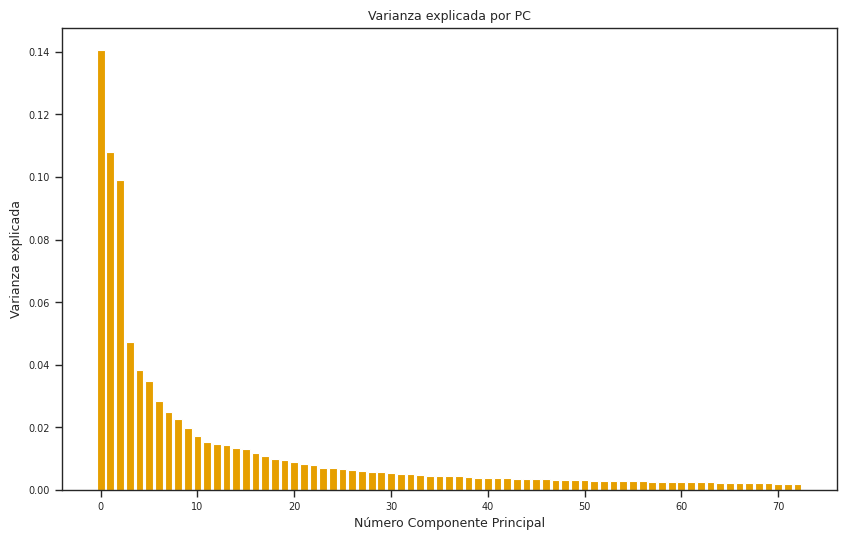

In [ ]:
#Uso de PCA para extracción de características relevantes

#Normalización de los datos
scaler = StandardScaler()

datos = parkinson_mean.drop(columns=['gender', 'id', 'class'], axis=1)
datos_norm = pd.DataFrame(scaler.fit_transform(datos))

#Número de componentes para obtener varianza:
varianza = 0.90

pca = PCA(n_components=varianza, whiten=True).fit(datos_norm)
datos_pca = pca.transform(datos_norm)
datos_pca = pd.DataFrame(datos_pca)

#Gráfico de los componentes principales creados
plt.figure(figsize=(10, 6))

plt.bar(range(len(pca.explained_variance_)), pca.explained_variance_ratio_)
plt.ylabel('Varianza explicada')
plt.xlabel('Número Componente Principal')
plt.title('Varianza explicada por PC')

print("Número de características en el dataset original:", datos.shape[1])
print("Número de características reducidas (número de PC):", len(pca.explained_variance_))

#Head de los principales 5 componentes principales
#datos_pca.iloc[:, 0:6].head()

#Matriz de correlación muestra la correlación nula entre componentes principales
# corr_matriz = datos_pca.corr().abs()
# sns.heatmap(corr_matriz, cmap="berlin", square=True)


# Bibliografía para la extracción de características con PCA
# https://www.geeksforgeeks.org/machine-learning/reduce-data-dimentionality-using-pca-python/
# https://medium.com/@andymdc31/using-pca-in-a-machine-learning-pipeline-b6fe3492b1b9
# https://www.aprendemachinelearning.com/comprende-principal-component-analysis/
# https://www.statology.org/scree-plot-python/


El uso de PCA muestra como el primer componente principal sólo representa el 0.14 de la varianza explicada. Para llegar a explicar el 90% de la varianza se necesitan 73 componentes principales.


In [ ]:
# Resultados normalizados y pca
def pipeline_norm_pca(modelo):
  steps=[
      ('scaler', StandardScaler()),
      ('pca', PCA(n_components=0.9)),
      ('model', modelo)
  ]
  return imbpipeline(steps)

resultados_base_pca = tabla_summary_modelos2(pipeline_norm_pca, lista_modelos, X2, y2)
resultados_base_pca

,Accuracy,F1-score,MCC,AUC-ROC,Modelo
0,0.802,0.868,0.471,0.786,Regresión Logística
0,0.790,0.875,0.352,0.803,KNN
0,0.774,0.846,0.425,0.777,SVM (lineal)
0,0.825,0.892,0.489,0.804,SVM (rbf)
0,0.790,0.874,0.352,0.746,Random Forest
0,0.825,0.892,0.490,0.775,XGBoost


Los resultados de rendimiento muestran resultados inferiores respecto a los valores basales. De este modo, no se considera la extracción de características como método para la reducción de la dimensionalidad en este caso.

# Desbalance de clases

El conjunto de datos muestra un desbalance de clases, donde el número de sujetos con EP triplica al de sujetos sanos. Como se ha comentado, esto supone un problema para los algoritmos de ML, ya que la mayoría esperan una distribución de clases equilibrada. Por ello, la primera estrategia es tener en cuenta métricas de rendimiento como el F1 y el MCC, que permiten evaluar los modelos teniendo en cuenta el desbalance de clases.

La segunda estrategia consiste en el uso de procedimientos adicionales que permitan corregir el desbalance de clases:

**SMOTE** (Synthetic Minority Over-sampling Technique): es una técnica de remuestreo que permite generar nuevas muestras sintéticas para la clase minoritaria

**class_weight**: está presente en distintos algoritmos de ML y permite asignar diferentes pesos a las clases del dataset. En este caso, daría una mayor importancia a la clase minoritaria, de sujetos control, y un peso menor a la clase de sujetos con EP.

Dado que class weight es un hiperparámetro ajustable para distintos modelos, se ha integrado la aplicación de ambas estrategias dentro del enfoque de GridSearch.

# Optimización de modelos: GridSearch

La mayoría de los modelos de ML contienen hiperparámetros que permiten ajustar su aprendizaje. Para evitar ir probando distintos valores de forma manual, se definen un conjunto de parámetros a estudiar y GridSearch prueba todas las combinaciones, seleccionando aquella que proporciona el mejor resultado.

A continuación, para cada uno de los algoritmos de estudio, se detalla los parámetros que se pueden ajustar. No se contempla un ajuste de todos los posibles hiperparámetros sino sólo de aquellos más relevantes. Asimismo, se ha utilizado la métrica **MCC** para la evaluación del mejor método, dado que es la métrica menos sensible al desbalance de clases.

En todos los algoritmos menos en Regresión Logística y en SVM, se ha activado el parámetro **n_jobs**, que especifica el número de núcleos de la CPU que trabajan en paralelo: "-1" permite el uso de todos los cores disponibles.

Por último, dentro del enfoque GridSearch se ha incluido el abordaje del desbalance de clases mediante SMOTE y class weight. Para ello, se han diseñado dos tipos de pipelines:

 - El primer pipeline incluye el hiperparámetro **class_weight** cuando el algoritmo lo ha permitido, para ajustar la penalización asociada al desbalance.

 - El segundo pipeline incorpora el uso de **SMOTE** posteriormente a la selección de características.

En algoritmos como KNN y XGBoost, que no incluyen el parámetro class weight dentro de su configuración, se ha comparado un primer pipeline sin tratamiento del desbalanceo y un segundo con aplicación de SMOTE.

Dados los resultados con selección de características obtenidos, se utilizará:

- **mRMR**: para los algoritmos de Regresión Logística, KNN y SVM (lineal).

- **LinearSVC**: para SVM (rbf) y Random Forest

- Combinación de características acústicas **MFCC y TQWT**: para XGBoost.


In [ ]:
#Función para la evaluación de GridSearch
seed=123

# pipeline_norm_base con smote
def pipeline_norm_smote(modelo):
  steps=[
      ('scaler', StandardScaler()),
      ('smote', SMOTE(sampling_strategy='minority', random_state=seed)),
      ('model', modelo)
  ]
  return imbpipeline(steps)

# pipeline_norm_mrmr_def con smote
def pipeline_norm_mrmr_smote(modelo):
    steps = [
        ('scaler', StandardScaler()),
        ('feature_selection', MRMR(method="FCQ", regression=False, random_state=123, max_features=50)),
        ('smote', SMOTE(sampling_strategy='minority', random_state=seed)),
        ('model', modelo)
    ]
    return imbpipeline(steps)

# pipeline_norm_linearsvc_def con smote
def pipeline_norm_linearsvc_smote(modelo):
    steps = [
        ('scaler', StandardScaler()),
        ('feature_selection', SelectFromModel(LinearSVC(penalty="l1", loss="squared_hinge", C=0.1, random_state=123))),
        ('smote', SMOTE(sampling_strategy='minority', random_state=seed)),
        ('model', modelo)
    ]
    return imbpipeline(steps)


#GridSearch
mcc_calcular = make_scorer(matthews_corrcoef)

def find_gridsearch(seleccion, hiperparametros, hiperparametros_smote, modelo):
  #MRMR
  if seleccion == "mrmr":
    #GS class_weight
    gs = GridSearchCV(pipeline_norm_mrmr_def(modelo),
                    param_grid=hiperparametros,
                    cv=kf.split(X2, y2),
                    scoring=mcc_calcular,
                    n_jobs=-1)
    gs.fit(X2, y2)
    print("Mejores parámetros: ", gs.best_params_)
    print("MCC con mejores parámetros: ", gs.best_score_)

    #GS smote
    gs_smote = GridSearchCV(pipeline_norm_mrmr_smote(modelo),
                    param_grid=hiperparametros_smote,
                    cv=kf.split(X2, y2),
                    scoring=mcc_calcular,
                    n_jobs=-1)

    gs_smote.fit(X2, y2)

    print("Mejores parámetros con SMOTE: ", gs_smote.best_params_)
    print("MCC con mejores parámetros con SMOTE: ", gs_smote.best_score_)

  #LinearSVC
  elif seleccion == "linearsvc":
    #GS class_weight
    gs = GridSearchCV(pipeline_norm_linearsvc_def(modelo),
                    param_grid=hiperparametros,
                    cv=kf.split(X2, y2),
                    scoring=mcc_calcular,
                    n_jobs=-1)
    gs.fit(X2, y2)
    print("Mejores parámetros: ", gs.best_params_)
    print("MCC con mejores parámetros: ", gs.best_score_)

    #GS smote
    gs_smote = GridSearchCV(pipeline_norm_linearsvc_smote(modelo),
                    param_grid=hiperparametros_smote,
                    cv=kf.split(X2, y2),
                    scoring=mcc_calcular,
                    n_jobs=-1)

    gs_smote.fit(X2, y2)

    print("Mejores parámetros con SMOTE: ", gs_smote.best_params_)
    print("MCC con mejores parámetros con SMOTE: ", gs_smote.best_score_)

  #XGBoost con selección de características acústicas
  else:
    #GS class_weight
    gs = GridSearchCV(pipeline_norm_base(modelo),
                    param_grid=hiperparametros,
                    cv=kf.split(lista_acusticos_combi1['MFCC_TQWT'], y2),
                    scoring=mcc_calcular,
                    n_jobs=-1)
    gs.fit(lista_acusticos_combi1['MFCC_TQWT'], y2)
    print("Mejores parámetros: ", gs.best_params_)
    print("MCC con mejores parámetros: ", gs.best_score_)

    #GS smote
    gs_smote = GridSearchCV(pipeline_norm_smote(modelo),
                    param_grid=hiperparametros_smote,
                    cv=kf.split(lista_acusticos_combi1['MFCC_TQWT'], y2),
                    scoring=mcc_calcular,
                    n_jobs=-1)

    gs_smote.fit(lista_acusticos_combi1['MFCC_TQWT'], y2)

    print("Mejores parámetros con SMOTE: ", gs_smote.best_params_)
    print("MCC con mejores parámetros con SMOTE: ", gs_smote.best_score_)


# Bibliografia
# https://www.geeksforgeeks.org/machine-learning/smote-for-imbalanced-classification-with-python/
# https://www.geeksforgeeks.org/machine-learning/handling-imbalanced-data-for-classification/
# https://medium.com/data-science/the-right-way-of-using-smote-with-cross-validation-92a8d09d00c7
# https://stackoverflow.com/questions/72749144/scikit-learn-pipeline-with-smote
# https://collinloo.medium.com/quick-comparison-between-random-oversampling-and-smote-4b6c433d7e7d
# https://stackoverflow.com/questions/67116536/how-to-use-matthews-coefficient-for-scoring-in-gridsearchcv

**Regresión logística**

Modificación de parámetros: **penalización** - L1 (LASSO) y L2 (Ridge); **C** (regularización inversa); y **solver** - liblinear y saga.



In [ ]:
# Optimización de Regresión Logística (32 min)

hiperparametros_rl1 = [
    {'model__penalty': ['l1','l2'],
    'model__C' : [0.1, 0.5, 1],
    'model__solver': ['liblinear', 'saga'],
    'model__class_weight': ['balanced', None]
    }]

hiperparametros_rl2 = [
    {'model__penalty': ['l1','l2'],
    'model__C' : [0.1, 0.5, 1],
    'model__solver': ['liblinear','saga'],
    'model__class_weight': [None]
    }]

find_gridsearch("mrmr", hiperparametros_rl1, hiperparametros_rl2, lista_modelos['Regresión Logística'])

#https://www.geeksforgeeks.org/machine-learning/how-to-optimize-logistic-regression-performance/
# https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html

Mejores parámetros:  {'model__C': 0.1, 'model__class_weight': None, 'model__penalty': 'l2', 'model__solver': 'saga'}
MCC con mejores parámetros:  0.6552306289682029
Mejores parámetros con SMOTE:  {'model__C': 1, 'model__class_weight': None, 'model__penalty': 'l1', 'model__solver': 'liblinear'}
MCC con mejores parámetros con SMOTE:  0.5797817908250367


**KNN**:

Modificación de parámetros: **K** (número de vecinos); **métrica de distancia (p)** - distancia Euclidiana (p=2) y distancia de Manhattan (p=1); **ponderación de los vecinos** - *uniform* y *distance*.

In [ ]:
# Optimización de KNN (27 min)

hiperparametros_knn = [
    {'model__n_neighbors': [5, 10, 15, 20, 25],
    'model__p': [1,2],
    'model__weights': ['uniform', 'distance']
    }]

find_gridsearch("mrmr", hiperparametros_knn, hiperparametros_knn, lista_modelos['KNN'])

#https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html
#https://www.datasklr.com/select-classification-methods/k-nearest-neighbors


Mejores parámetros:  {'model__n_neighbors': 20, 'model__p': 2, 'model__weights': 'distance'}
MCC con mejores parámetros:  0.5392647239114555
Mejores parámetros con SMOTE:  {'model__n_neighbors': 25, 'model__p': 1, 'model__weights': 'distance'}
MCC con mejores parámetros con SMOTE:  0.47534462406090466


**SVM**:

Modificación de parámetros: **kernel** - 'linear' y 'rbf'; **C** (coste);  **gamma**.

En el caso de SVM con kernel lineal, al utilizar LinearSVC, no se incluye el parámetro gamma.



In [ ]:
# Optimización de SVM kernel lineal
hiperparametros_svm_l1 = [
    {'model__C': [0.001, 0.01,  0.1, 1, 2],
     'model__class_weight': ['balanced', None],
    }]

hiperparametros_svm_l2 = [
    {'model__C' : [0.001, 0.01,  0.1, 1, 2],
     'model__class_weight': [None]
    }]

find_gridsearch("mrmr", hiperparametros_svm_l1, hiperparametros_svm_l2, lista_modelos['SVM (lineal)'])

#https://medium.com/analytics-vidhya/hyperparameter-tuning-an-svm-a-demonstration-using-hyperparameter-tuning-cross-validation-on-96b05db54e5b
#https://scikit-learn.org/stable/modules/generated/sklearn.svm.LinearSVC.html

Mejores parámetros:  {'model__C': 0.01, 'model__class_weight': None}
MCC con mejores parámetros:  0.650878315066412
Mejores parámetros con SMOTE:  {'model__C': 0.1, 'model__class_weight': None}
MCC con mejores parámetros con SMOTE:  0.5578984486366347


In [ ]:
# Optimización de SVM kernel rbf
hiperparametros_svm_rbf1 = [
    {'model__C': [0.01, 0.05, 0.1, 0.25, 0.5, 0.75, 1, 3, 5, 7, 10],
    'model__gamma': [0.0001, 0.001, 0.005, 0.01, 0.025, 0.05, 0.1, 1],
    'model__class_weight': ['balanced', None]
    }]

hiperparametros_svm_rbf2 = [
    {'model__C' : [0.001, 0.005, 0.01, 0.05, 0.1, 0.25, 0.5],
    'model__gamma': [0.0001, 0.001, 0.005, 0.01, 0.025, 0.05, 0.1, 1],
    'model__class_weight': [None]
    }]

find_gridsearch("linearsvc", hiperparametros_svm_rbf1, hiperparametros_svm_rbf2, lista_modelos['SVM (rbf)'] )

# https://www.geeksforgeeks.org/machine-learning/svm-hyperparameter-tuning-using-gridsearchcv-ml/
# https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html

Mejores parámetros:  {'model__C': 5, 'model__class_weight': None, 'model__gamma': 0.001}
MCC con mejores parámetros:  0.616879606373004
Mejores parámetros con SMOTE:  {'model__C': 0.001, 'model__class_weight': None, 'model__gamma': 0.001}
MCC con mejores parámetros con SMOTE:  0.6036512994609005


**Random Forest**

Modificación de parámetros: **n_estimators** (número de árboles); **max_depth** (profundidad máxima de cada árbol); **max_features** (número de características utilizadas para decidir la mejor división en cada nodo).

In [ ]:
# Optimización de Random forest
hiperparametros_rf1 = [
    {'model__max_depth': [3, 5, 6, 10],
     'model__n_estimators': [50, 100, 150, 200, 300],
     'model__max_features': [10, 15, 20, 30],
     'model__class_weight': ["balanced", None]
    }]

hiperparametros_rf2 = [
    {'model__max_depth': [3, 5, 6, 10],
     'model__n_estimators': [50, 100, 150, 200, 300],
     'model__max_features': [10, 15, 20, 30],
     'model__class_weight': [None]
    }]

find_gridsearch("linearsvc", hiperparametros_rf1, hiperparametros_rf2, lista_modelos['Random Forest'])

# https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html
# https://www.blog.trainindata.com/random-forest-with-grid-search/

Mejores parámetros:  {'model__class_weight': None, 'model__max_depth': 5, 'model__max_features': 20, 'model__n_estimators': 100}
MCC con mejores parámetros:  0.5886904623157626
Mejores parámetros con SMOTE:  {'model__class_weight': None, 'model__max_depth': 10, 'model__max_features': 10, 'model__n_estimators': 50}
MCC con mejores parámetros con SMOTE:  0.570303218121434


**XGBoost**

Modificación de parámetros: **n_estimators**, **learning_rate** y **max_depth**.

In [ ]:
# Optimización de XGboost
hiperparametros_xgb1 = [
    {'model__max_depth': [1,5,10,12],
     'model__n_estimators': [10, 50, 100, 150, 200],
     'model__learning_rate': [0.01, 0.1, 0.3, 0.5]
    }]

find_gridsearch("XGBoost", hiperparametros_xgb1, hiperparametros_xgb1, lista_modelos['XGBoost'])

# https://xgboost.readthedocs.io/en/stable/parameter.html
# https://www.kaggle.com/code/alexisbcook/xgboost

Mejores parámetros:  {'model__learning_rate': 0.1, 'model__max_depth': 5, 'model__n_estimators': 200}
MCC con mejores parámetros:  0.5693792840746432
Mejores parámetros con SMOTE:  {'model__learning_rate': 0.1, 'model__max_depth': 10, 'model__n_estimators': 200}
MCC con mejores parámetros con SMOTE:  0.58769828780076


## **Modelo óptimo**


Teniendo en cuenta los mejores hiperparámetros definidos por GridSearch, se elabora una tabla final con la mejor configuración de cada modelo.



In [ ]:
#Configuración final de modelos
seed = 123

#Regresión logística
RL = LogisticRegression(
    C=0.1,
    class_weight =None,
    penalty = 'l2',
    solver = 'saga',
    random_state=seed)

#k-Nearest Neighbors
KNN = KNeighborsClassifier(
    n_neighbors=20,
    p=2,
    weights='distance',
    n_jobs=-1)

# Support Vector Machine: Kernel lineal
SVM_linear = LinearSVC(
                 C=0.01,
                 class_weight=None,
                 random_state=seed)

# Support Vector Machine: Kernel RBF
SVM_rbf = SVC(
    kernel='rbf',
    C=5,
    class_weight=None,
    gamma=0.001,
    random_state=seed,
    probability=False)

#Random forest
RF = RandomForestClassifier(
    n_estimators=100,
    max_features=20,
    max_depth=5,
    class_weight=None,
    random_state=seed,
    n_jobs=-1)

#Gradient boosting: XGboost
XGboost = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=10,
    random_state=seed,
    n_jobs=-1)

#Lista de modelos
lista_modelos_mrmr = {"Regresión Logística": RL, "KNN": KNN, "SVM (lineal)":SVM_linear}
lista_modelos_linearsvc = {"SVM (rbf)": SVM_rbf, "Random Forest": RF}

In [ ]:
#Representación de resultados para modelos con configuración óptima

tabla_final = pd.DataFrame()
for (key, value) in lista_modelos_mrmr.items():
  modelo_mrmr = make_metricas2(pipeline_norm_mrmr_def, value, X2, y2)
  modelo_mrmr['Modelo'] = str(key)
  tabla_final = pd.concat([tabla_final, modelo_mrmr], ignore_index=True)
for (key, value) in lista_modelos_linearsvc.items():
  modelo_linearsvc = make_metricas2(pipeline_norm_linearsvc_def, value, X2, y2)
  modelo_linearsvc['Modelo'] = str(key)
  tabla_final = pd.concat([tabla_final, modelo_linearsvc], ignore_index=True)

xgboost_smote = make_metricas2(pipeline_norm_smote, XGboost, lista_acusticos_combi1['MFCC_TQWT'], y2)
xgboost_smote['Modelo'] = "XGBoost"

tabla_final = pd.concat([tabla_final, xgboost_smote], ignore_index=True)
tabla_final

,Accuracy,F1-score,MCC,AUC-ROC,Modelo
0,0.873,0.918,0.646,0.866,Regresión Logística
1,0.841,0.902,0.546,0.845,KNN
2,0.869,0.915,0.638,0.859,SVM (lineal)
3,0.865,0.915,0.620,0.836,SVM (rbf)
4,0.853,0.909,0.583,0.837,Random Forest
5,0.845,0.899,0.575,0.884,XGBoost


**Representación de resultados para los modelos óptimos**

A continuación se representan las matrices de confusión y las curvas ROC para los modelos optimizados.

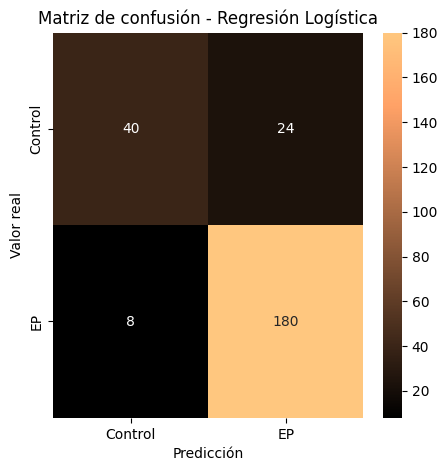

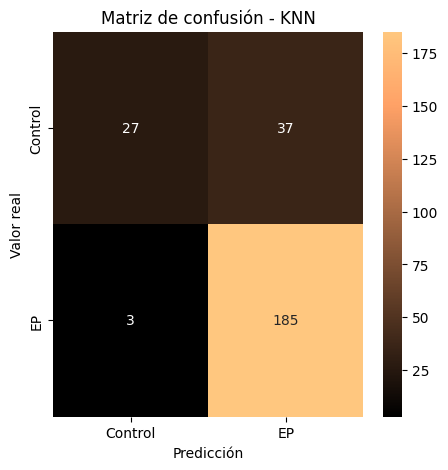

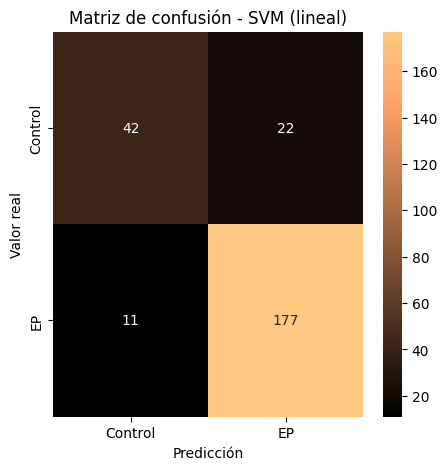

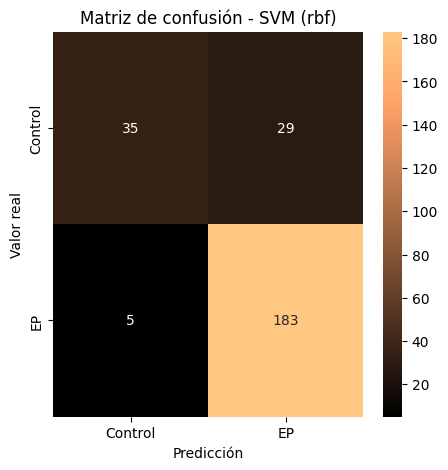

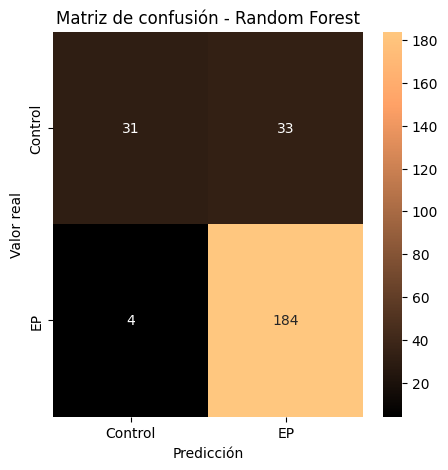

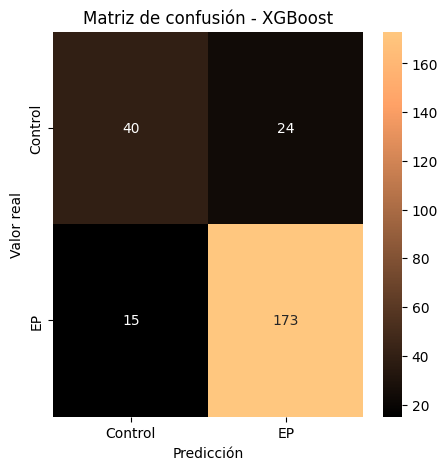

In [ ]:
## Matrices de confusión

from sklearn.metrics import confusion_matrix

y2 = parkinson_mean['class']
X2 = parkinson_mean.drop(['class', 'id'], axis=1)

kf = StratifiedKFold(n_splits=10, shuffle=True, random_state=123)

def make_matriz_confusion(pipeline, modelo, nombre_modelo, X, y):
  y_test_postcv = []
  y_test_prediccion = []
  y_probabilidades = []

  for train_index, test_index in kf.split(X, y):
    X_train = X.iloc[train_index]
    y_train = y.iloc[train_index]
    X_test = X.iloc[test_index]
    y_test = y.iloc[test_index]

    #Pipeline
    pipeline_ml = pipeline(modelo)

    pipeline_ml.fit(X_train, y_train)


    #Predicciones
    predicciones = pipeline_ml.predict(X_test)

    if isinstance(modelo, (LinearSVC, SVC)):
      prob_predicciones = pipeline_ml.decision_function(X_test)
    else:
      prob_predicciones = pipeline_ml.predict_proba(X_test)[:, 1] #necesario para el cálculo de auc-roc

    #Añadirlas a las listas
    y_test_prediccion.extend(predicciones)
    y_probabilidades.extend(prob_predicciones)
    y_test_postcv.extend(y_test)

  #Plot Matriz de confusión
  plt.figure(figsize=(5,5))
  mat = confusion_matrix(y_test_postcv, y_test_prediccion)
  cm_plot = sns.heatmap(mat, yticklabels=["Control", "EP"], xticklabels=["Control", "EP"], annot=True, fmt="d", cmap= "copper")
  cm_plot.set(xlabel="Predicción", ylabel="Valor real")
  plt.title(f"Matriz de confusión - {nombre_modelo}")

# Gráficos de las seis matrices de confusión
for (key, value) in lista_modelos_mrmr.items():
  make_matriz_confusion(pipeline_norm_mrmr_def, value, key, X2, y2)

for (key, value) in lista_modelos_linearsvc.items():
  make_matriz_confusion(pipeline_norm_linearsvc_def, value, key, X2, y2)

make_matriz_confusion(pipeline_norm_smote, XGboost, "XGBoost", lista_acusticos_combi1['MFCC_TQWT'], y2)

plt.show()

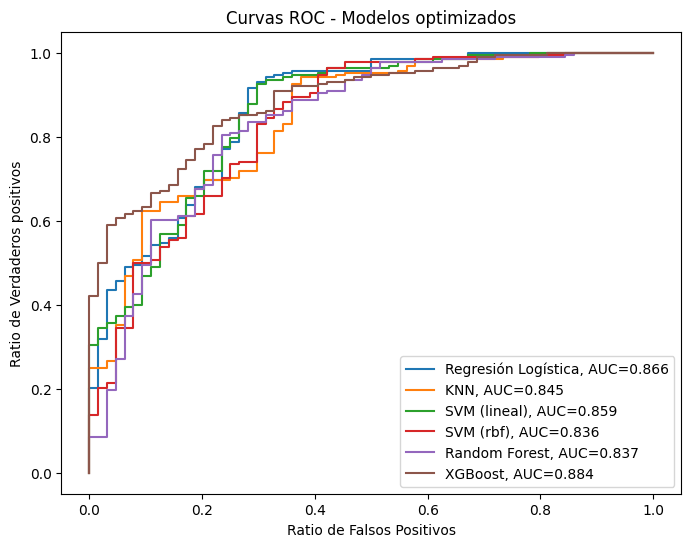

In [ ]:
## Representación de curvas ROC de modelos óptimos

from sklearn import metrics

y2 = parkinson_mean['class']
X2 = parkinson_mean.drop(['class', 'id'], axis=1)

kf = StratifiedKFold(n_splits=10, shuffle=True, random_state=123)

plt.figure(figsize=(8,6))


def make_roc_curve(pipeline, modelo, nombre_modelo, X, y):

  #print("Entrenando modelo:", {modelo})

  y_test_postcv = []
  y_test_prediccion = []
  y_probabilidades = []

  for train_index, test_index in kf.split(X, y):
    X_train = X.iloc[train_index]
    y_train = y.iloc[train_index]
    X_test = X.iloc[test_index]
    y_test = y.iloc[test_index]

    #Pipeline
    pipeline_ml = pipeline(modelo)

    pipeline_ml.fit(X_train, y_train)

    #Predicciones
    predicciones = pipeline_ml.predict(X_test)

    if isinstance(modelo, (LinearSVC, SVC)):
      prob_predicciones = pipeline_ml.decision_function(X_test)
    else:
      prob_predicciones = pipeline_ml.predict_proba(X_test)[:, 1] #necesario para el cálculo de auc-roc

    #Añadirlas a las listas
    y_test_prediccion.extend(predicciones)
    y_probabilidades.extend(prob_predicciones)
    y_test_postcv.extend(y_test)

  #Curva ROC
  fpr, tpr, _ = metrics.roc_curve(y_test_postcv, y_probabilidades)
  auc = round(metrics.roc_auc_score(y_test_postcv, y_probabilidades), 3)
  return plt.plot(fpr, tpr, label=f"{nombre_modelo}, AUC="+str(auc))

# Print de las curvas ROC
for (key, value) in lista_modelos_mrmr.items():
  make_roc_curve(pipeline_norm_mrmr_def, value, key, X2, y2)

for (key, value) in lista_modelos_linearsvc.items():
  make_roc_curve(pipeline_norm_linearsvc_def, value, key, X2, y2)

make_roc_curve(pipeline_norm_smote, XGboost, "XGBoost", lista_acusticos_combi1['MFCC_TQWT'], y2)


plt.legend()

plt.xlabel("Ratio de Falsos Positivos")
plt.ylabel("Ratio de Verdaderos positivos")
plt.title("Curvas ROC - Modelos optimizados")
plt.legend()
plt.show()

# Bibliografia creación curvas ROC en un sólo gráfico
# https://www.statology.org/plot-multiple-roc-curves-python/



# Interpretabilidad del modelo: SHAP

SHAP, en inglés Shapley Additive Explanations, es una biblioteca de Python que se utiliza para explicar el resultado de los modelos de ML y mostrar qué características han tenido una mayor contribución en la predicción.

Teniendo en cuenta el modelo con mejor rendimiento, se ha utilizado SHAP para estudiar cuáles de las características acústicas han aportado más información en la predicción del modelo.



Estimating transforms:   0%|          | 0/1000 [00:00<?, ?it/s]

Estimating transforms:   0%|          | 0/1000 [00:00<?, ?it/s]

Estimating transforms:   0%|          | 0/1000 [00:00<?, ?it/s]

Estimating transforms:   0%|          | 0/1000 [00:00<?, ?it/s]

Estimating transforms:   0%|          | 0/1000 [00:00<?, ?it/s]

Estimating transforms:   0%|          | 0/1000 [00:00<?, ?it/s]

Estimating transforms:   0%|          | 0/1000 [00:00<?, ?it/s]

Estimating transforms:   0%|          | 0/1000 [00:00<?, ?it/s]

Estimating transforms:   0%|          | 0/1000 [00:00<?, ?it/s]

Estimating transforms:   0%|          | 0/1000 [00:00<?, ?it/s]

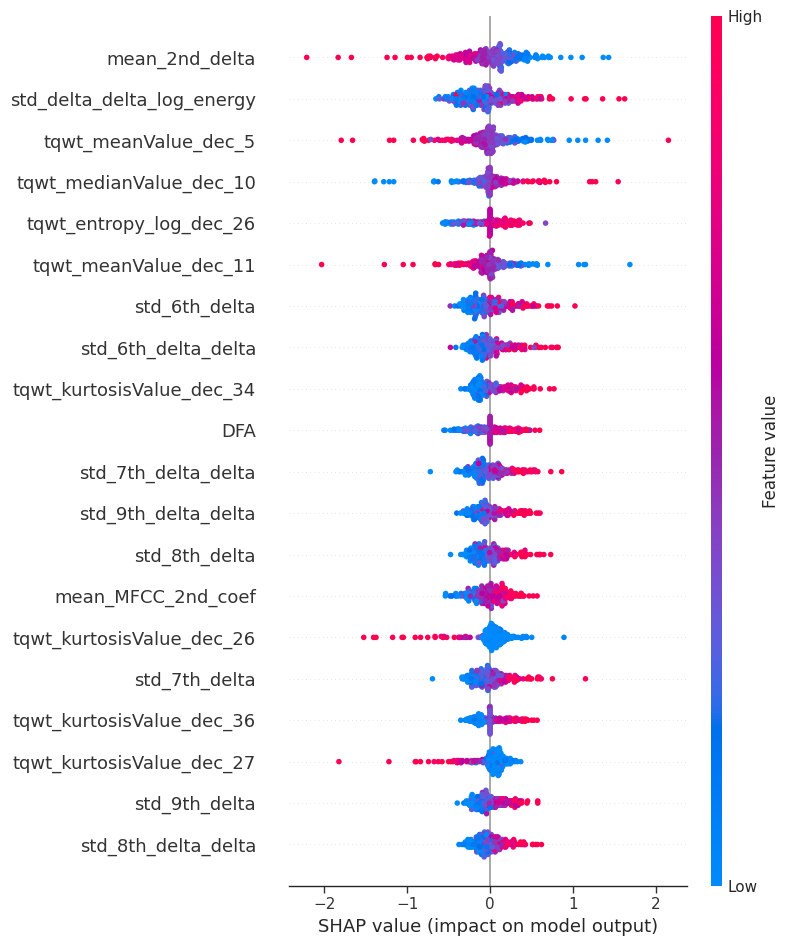

In [ ]:
y2 = parkinson_mean['class']
X2 = parkinson_mean.drop(['class', 'id'], axis=1)

kf = StratifiedKFold(n_splits=10, shuffle=True, random_state=123)

# Listas para acumular valores SHAP e índices test
SHAP_values_x_iteracion = []
X_test_x_iteracion = []
ix_test = []

#Bucle CV
for train_index, test_index in kf.split(X2, y2):
    ix_test.append(test_index)

    X_train = X2.iloc[train_index]
    y_train = y2.iloc[train_index]
    X_test = X2.iloc[test_index]
    y_test = y2.iloc[test_index]

    pipeline_ml = pipeline_norm_mrmr_def(lista_modelos_mrmr['Regresión Logística'])
    pipeline_ml.fit(X_train, y_train)

    #X_train
    X_train_escalado = pipeline_ml['scaler'].transform(X_train)
    X_train_caract = pipeline_ml['feature_selection'].transform(X_train_escalado)

    # X_test
    X_test_escalado = pipeline_ml['scaler'].transform(X_test)
    X_test_caract = pipeline_ml['feature_selection'].transform(X_test_escalado)

    #Características seleccionadas por mRMR en esta iteración
    columnas_select = pipeline_ml['feature_selection'].get_support() # Permite obtener los nombres de las características seleccionadas
    caracteristicas_select = X2.columns[columnas_select]

    # SHAP
    explainer = shap.LinearExplainer(pipeline_ml['model'], X_train_caract, feature_perturbation="correlation_dependent")
    shap_values = explainer.shap_values(X_test_caract)

    # Alineación de características:
    # Como mRMR puede seleccionar variables distintas en cada fold, creamos plantillas vacías (con ceros) para todas las columnas originales.
    shap_df_x_iteracion = pd.DataFrame(0.0, index=range(len(test_index)), columns=X2.columns)
    test_df_x_iteracion = pd.DataFrame(0.0, index=range(len(test_index)), columns=X2.columns)

    # Asignamos valores SHAP y test calculados únicamente en las posiciones de las variables seleccionadas
    shap_df_x_iteracion[caracteristicas_select] = shap_values
    test_df_x_iteracion[caracteristicas_select] = X_test_caract

    # Acumulación de resultados del fold
    SHAP_values_x_iteracion.extend(shap_df_x_iteracion.values)
    X_test_x_iteracion.extend(test_df_x_iteracion.values)

# Gráfico Final
shap.summary_plot(
    np.array(SHAP_values_x_iteracion),
    np.array(X_test_x_iteracion),
    feature_names=X2.columns
)


#Bibiliografia para la construcción de SHAP plot con CV
# https://stackoverflow.com/questions/72720106/shap-values-with-cross-validation-do-i-implement-the-shap-values-on-axis-0-or
# https://lucasramos-34338.medium.com/visualizing-variable-importance-using-shap-and-cross-validation-bd5075e9063a
# https://shap.readthedocs.io/en/latest/generated/shap.KernelExplainer.html
# https://www.geeksforgeeks.org/machine-learning/shap-with-a-linear-svc-model-from-sklearn-using-pipeline/

# Apéndice

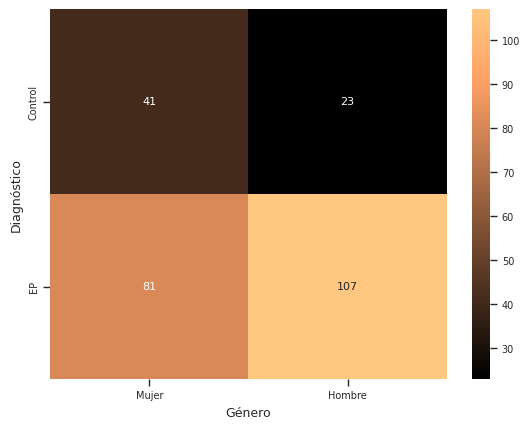

In [ ]:
## Crosstable para las variables Diagnóstico y Género
ct_data = sns.heatmap(pd.crosstab(parkinson_mean["class"], parkinson_mean["gender"]),
            yticklabels=["Control", "EP"],
            xticklabels=["Mujer", "Hombre"],
            annot=True, fmt="d", cmap= "copper")
ct_data.set(xlabel="Género", ylabel="Diagnóstico")
plt.show()

# Bibliografía heatmap seaborn
# https://seaborn.pydata.org/generated/seaborn.heatmap.html
# https://matplotlib.org/stable/users/explain/colors/colormaps.html